## **1.IMPORTS**

This jupyter notebook  uses `my_recommender_package` library.
Make sure the package is installed from GitHub before running this notebook:
`pip install git+https://github.com/vicentmwanda/recommender_system.git`    

In [1]:
from my_recommender_package.data_structure import MyDataStruct
from my_recommender_package.model import RecommenderModel,get_movie_data
from my_recommender_package.ALS_operations import (SEED, update_item_biases_only_parallel, update_user_biases_only_parallel 
                                                  , compute_rmse_bias_only_parallel)
from my_recommender_package.custom_utils import *

from datetime import datetime

import matplotlib.pyplot as plt

from matplotlib.lines import Line2D

from sklearn.decomposition import PCA

from numba.typed import List
from dotenv import load_dotenv
import numpy as np
import os
import gc

In [2]:
#load movie api keys:
sys_path=os.getcwd()
load_dotenv(os.path.join(sys_path, '.env'))

OMDB_API_KEY=os.getenv("OMDB") 
TMDB_API_KEY=os.getenv("TMDB") 

In [3]:
np.random.seed(SEED)

## **2. DATASET PATHS**

In [4]:
#!curl -O  'https://files.grouplens.org/datasets/movielens/ml-32m.zip'
#!curl -O  'https://files.grouplens.org/datasets/movielens/ml-latest-small.zip'

#PATH = 'drive/MyDrive/ml_scale/ml-latest-small'
#DATA_TITLE = '100k'

PATH = 'drive/MyDrive/ml_scale/ml-32m'
DATA_TITLE = '32M'

#creating folders for saving files, if not existing
create_storage_dirs('drive/MyDrive/ml_scale/')

## **3.DATA STRUCTURE INSTANCE & TRAIN SPLIT DATA ONLOAD**

In [5]:
SPLIT_STRATEGY='item'
#creating new data structure instance
data_structure=MyDataStruct(PATH,train_split = 0.1, split_strategy=SPLIT_STRATEGY, OMDB_api_key=OMDB_API_KEY,TMDB_api_key=TMDB_API_KEY)
#loading the rating data from csv file
data_structure.load_data('ratings.csv')
#loading the movie meta data from csv file (genres and movie links)
data_structure.load_item_data('movies.csv','links.csv')

started loading data
started reading data!
reading data completed!
Cleaning train test split
data loading completed!
###data structure optimization started
optimizing training data
optimizing test data
###data structure optimization started!
###train split completed!

######### TRAIN SPLIT RESULTS (TARGET RATIO: 10.00%) ############
Strategy: By movie

Train count:28829142
Test count:3171062

Total count:32000204

Final Train/Test split: 9.91 %

Data loading & Train Split Duration: 50.243 seconds
###############################################################################################
         
started loading genre/feature data
started reading data!
reading data completed!
data loading completed!
started loading link data
started reading data!
reading data completed!
data loading completed!
optimizing features data
optimizing completed


# **4.DATA EXPLORATION AND RATING DISTRIBUTIONS**


### **4.1 Train Test Split Results**

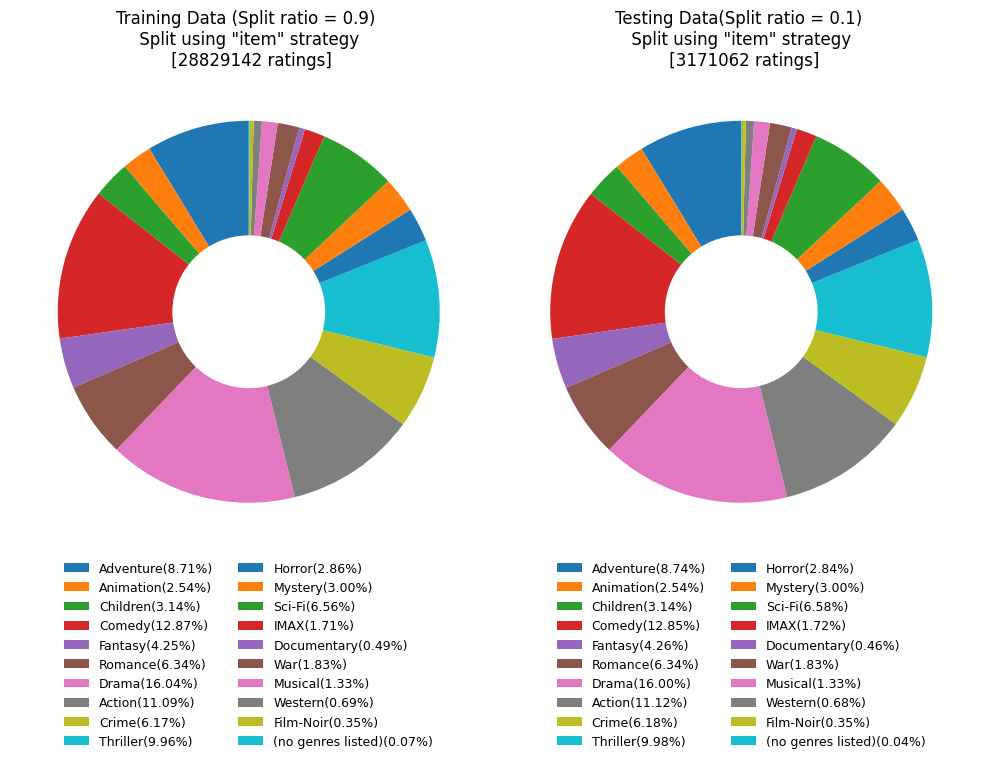

In [6]:
# get list of all genre labels
genre_labels = data_structure.genre_labels

# initialize counters: number of movies per genre for test and train data
genre_rating_counts_train={genre:0 for genre in genre_labels}
genre_rating_counts_test={genre:0 for genre in genre_labels}

# get all movie IDs in the dataset
movies_ids_train = data_structure.movie_id_to_data_idx_train.keys()
movies_ids_test = data_structure.movie_id_to_data_idx_test.keys()

# loop through each movie and compute genre statistics for train data
data_set = [
    [movies_ids_train,genre_rating_counts_train],
    [movies_ids_test,genre_rating_counts_test]
]
for index, data in enumerate(data_set):
            for id in data[0]:
                # get the genre list/string for this movie
                genre_info=data_structure.get_movie_data(id)['genre']
                #counting rating for genre
                if(index  == 1):
                       #for test set
                       rating_data=data_structure.get_data_by_movie_test(id)
                else:
                       #for train set
                       rating_data=data_structure.get_data_by_movie_train(id)
                count=len(rating_data)
                # match the movie against each genre label
                for genre in genre_labels:
                    if genre.lower() in genre_info.lower():
                        data[1][genre]+=count

#preparing data labels

labels=[]
for _, data in data_set:
       total=np.sum(list(data.values()))
       labels.append([f'{label}({data[label]/total*100:.2f}%)' for label in genre_labels])
         

#plotting genre distribution pie chart
final_split=data_structure.get_final_train_split()/100
ratings_train =data_structure.train_count
ratings_test =data_structure.test_count

fig, axs = plt.subplots(1, 2, figsize=(10, 8))

title=[
    f'Training Data (Split ratio = {(1-final_split):.1f}) \n Split using "{SPLIT_STRATEGY}" strategy \n [{ratings_train} ratings]',
    f'Testing Data(Split ratio = {final_split:.1f}) \n Split using "{SPLIT_STRATEGY}" strategy \n [{ratings_test} ratings]']
for index,(_, data) in enumerate(data_set):
            
            wedges, _ = axs[index].pie(
                            data.values(), 
                            startangle=90, 
                            labeldistance=1,
                            textprops={'fontsize': 8}
                            )
            # annotate manually
            axs[index].legend(
                wedges,
                labels[index],
                loc='upper center',    
                bbox_to_anchor=(0.5, 0), 
                fontsize=9,
                ncol=2,  
                frameon=False
            )

            centre_circle = plt.Circle((0, 0), 0.40, color='white', fc='white', linewidth=0)
            axs[index].add_patch(centre_circle)

            axs[index].set_title(title[index])
            fig.tight_layout()


plt.savefig(f'drive/MyDrive/ml_scale/results/{SPLIT_STRATEGY}_split/data_exploration/train_split_distribution_{SPLIT_STRATEGY}_split_{DATA_TITLE}_dataset.pdf'
           ,format='pdf',dpi=300)
plt.show()


### **4.2 Movie Rating Frequency**

In [7]:
# getting the data by all movies
movie_data=data_structure.get_data_by_movies()
# getting the number of ratigns for the movies
movie_degrees = [len(movie_rating) for  movie_rating in movie_data]

movie_frequency={}
# counting the frequency of the ratings
for degree in movie_degrees:
    if degree in movie_frequency:
        movie_frequency[degree]+=1
    else:
        movie_frequency[degree]=1
#converting the data to numpy
movie_degree_axis=np.array(list(movie_frequency.keys()))
movie_frequency_axis=np.array(list(movie_frequency.values()))


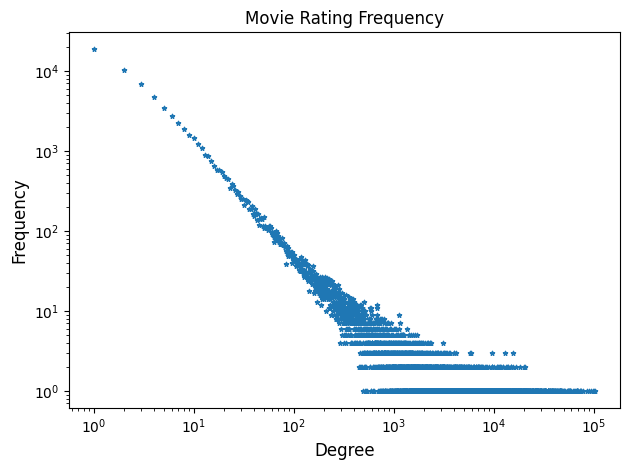

In [8]:
# plotting the movie rating frequency
plt.scatter(movie_degree_axis,movie_frequency_axis ,marker='*', s=10)
plt.title("Movie Rating Frequency", fontsize=12)
plt.xlabel("Degree", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.yscale('log')
plt.xscale('log')
plt.tight_layout()
# saving the plot to file
plt.savefig(f'drive/MyDrive/ml_scale/results/{SPLIT_STRATEGY}_split/data_exploration/movie_rating_frequency_{SPLIT_STRATEGY}_split_{DATA_TITLE}_dataset.pdf'
          ,format='pdf',dpi=300)
plt.show()

### **4.3 Power Law Plot(Movie Rating)**

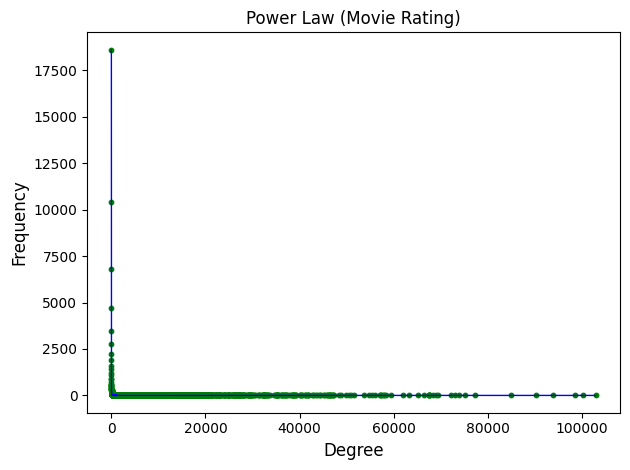

In [9]:
# plotting the power law based on the movie plots
plt.scatter(movie_degree_axis,movie_frequency_axis ,marker='o',color='green', s=10)
idx = np.argsort(movie_degree_axis)
plt.plot(movie_degree_axis[idx],movie_frequency_axis[idx],'b-',lw=1)
plt.title("Power Law (Movie Rating)", fontsize=12)
plt.xlabel("Degree", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.tight_layout()
# saving the plot to file
plt.savefig(f'drive/MyDrive/ml_scale/results/{SPLIT_STRATEGY}_split/data_exploration/power_law_movie_rating_{SPLIT_STRATEGY}_split_{DATA_TITLE}_dataset.pdf',format='pdf',
           dpi=300)
plt.show()

### **4.4 User Rating Frequency**

In [10]:
# getting the number of ratings by user data
user_degrees = [len(user_rating) for  user_rating in data_structure.get_data_by_users()]
user_frequency={}

# counting the frequency of the ratings
for degree in user_degrees:
    if degree in user_frequency:
        user_frequency[degree]+=1
    else:
        user_frequency[degree]=1
#converting the data to numpy
user_degree_axis=np.array(list(user_frequency.keys()))
user_frequency_axis=np.array(list(user_frequency.values()))

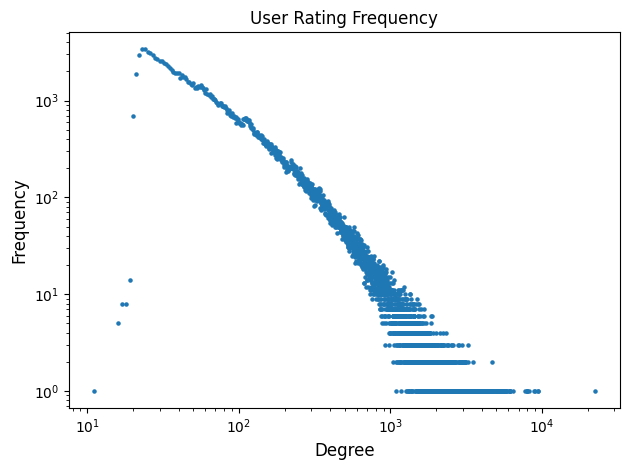

In [11]:
# plotting the user rating frequeny
plt.scatter(user_degree_axis,user_frequency_axis ,marker='o', s=5)
plt.title("User Rating Frequency", fontsize=12)
plt.xlabel("Degree", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.yscale('log')
plt.xscale('log')
plt.tight_layout()
#saving the plot to file
plt.savefig(f'drive/MyDrive/ml_scale/results/{SPLIT_STRATEGY}_split/data_exploration/user_rating_frequency_{SPLIT_STRATEGY}_split_{DATA_TITLE}_dataset.pdf',format='pdf',dpi=300)
plt.show()

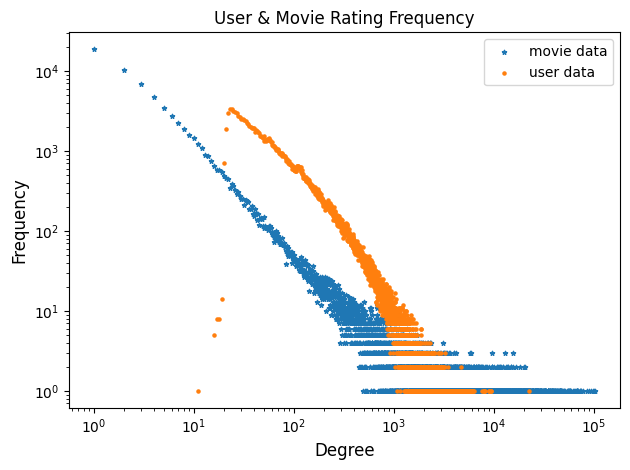

In [12]:
# plotting the user and movie rating frequency on same graph
plt.scatter(movie_degree_axis,movie_frequency_axis ,marker='*', s=10,label='movie data')
plt.scatter(user_degree_axis,user_frequency_axis ,marker='o', s=5,label='user data')
plt.title("User & Movie Rating Frequency", fontsize=12)
plt.xlabel("Degree", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.yscale('log')
plt.xscale('log')
plt.legend(loc='upper right')
plt.tight_layout()
# saving plot to file
plt.savefig(f'drive/MyDrive/ml_scale/results/{SPLIT_STRATEGY}_split/data_exploration/user_movie_rating_frequency_{SPLIT_STRATEGY}_split_{DATA_TITLE}_dataset.pdf',format='pdf',dpi=300)
plt.show()

### **4.4.Power Law Plot (User Rating)**

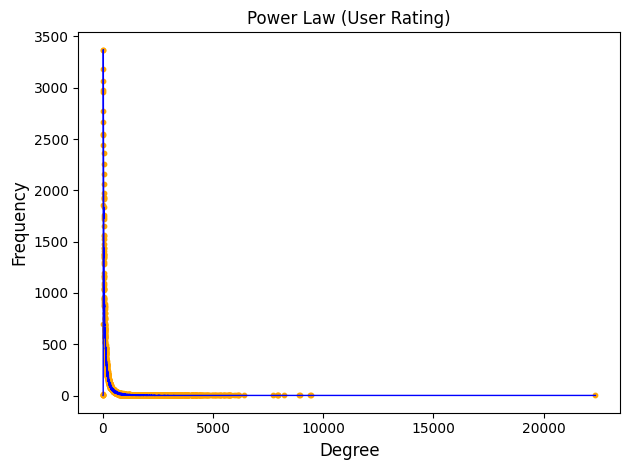

In [13]:
# plotting power law based user data
plt.scatter(user_degree_axis,user_frequency_axis ,marker='o', s=10,color='orange')
idx2 = np.argsort(user_degree_axis)
plt.plot(user_degree_axis[idx2],user_frequency_axis[idx2],'b-',lw=1)
plt.title("Power Law (User Rating)", fontsize=12)
plt.xlabel("Degree", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.tight_layout()
# saving plot to file
plt.savefig(f'drive/MyDrive/ml_scale/results/{SPLIT_STRATEGY}_split/data_exploration/power_law_user_rating_{SPLIT_STRATEGY}_split_{DATA_TITLE}_dataset.pdf',format='pdf',dpi=300)
plt.show()

### **4.5 Histogram of Rating Counting**

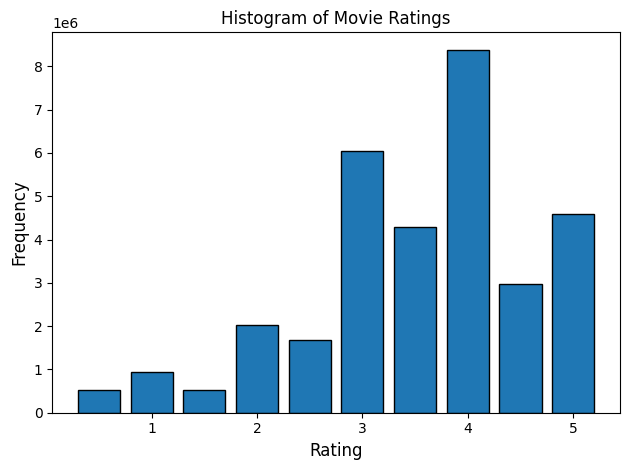

In [14]:
#accessing the ratings for the dataset
ratings = list(data_structure.rating_counts.keys())
counts = list(data_structure.rating_counts.values())
# plotting histogram of movies ratings and their frequency
plt.bar(ratings, counts, width=0.4, edgecolor='black')
plt.title("Histogram of Movie Ratings", fontsize=12)
plt.xlabel("Rating", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.tight_layout()
#saving plot to file
plt.savefig(f'drive/MyDrive/ml_scale/results/{SPLIT_STRATEGY}_split/data_exploration/movie_rating_histogram_{SPLIT_STRATEGY}_split_{DATA_TITLE}_dataset.pdf',format='pdf',dpi=300)
plt.show()

## **4.6 Genre Histogram**

In [15]:
# get list of all genre labels
genre_labels = data_structure.genre_labels
# initialize counters: total ratings per genre
genre_counts={genre:0 for genre in genre_labels}
# initialize counters: number of movies per genre
genre_movie_counts={genre:0 for genre in genre_labels}
# initialize dictionary to hold running average ratings per genre
genre_avg_ratings={genre:0 for genre in genre_labels}
# get all movie IDs in the dataset
movies_ids = data_structure.idx_to_movie_id
# loop through each movie and compute genre statistics
for id in movies_ids:
    # get the genre list/string for this movie
    genre_info=data_structure.get_movie_data(id)['genre']
    rating_data=data_structure.get_data_by_movie_id(id)
    movie_user_count=len(rating_data)
    # match the movie against each genre label
    for genre in genre_labels:
         if genre.lower() in genre_info.lower():
             genre_movie_counts[genre]+=1
             current_count=genre_counts[genre]
             genre_avg_ratings[genre]*=current_count
             for rating in rating_data:
                     genre_avg_ratings[genre]+=rating
             genre_counts[genre]+=movie_user_count
             genre_avg_ratings[genre]/=genre_counts[genre]

# convert data to numpy array
genre_axis=np.array(list(genre_labels))
genre_rating_frequency_axis=np.array(list(genre_counts.values()))
genre_movie_frequency_axis=np.array(list(genre_movie_counts.values()))
genre_rating_axis=np.array(list(genre_avg_ratings.values()))



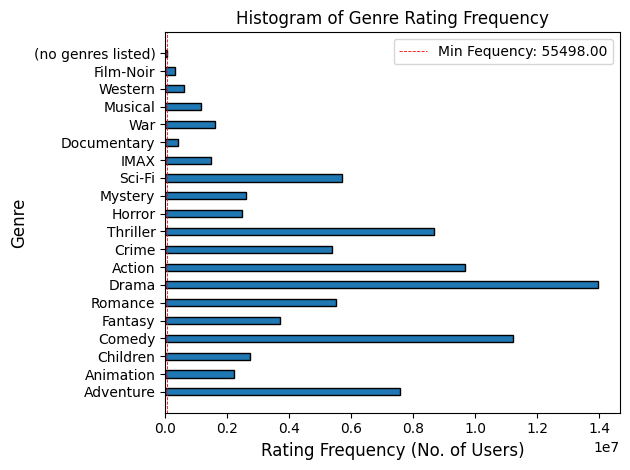

In [16]:
# plotting histogram of genre frequency
plt.barh(genre_axis, genre_rating_frequency_axis, height=0.4, edgecolor='black')
plt.title("Histogram of Genre Rating Frequency", fontsize=12)
plt.ylabel("Genre", fontsize=12)
plt.xlabel("Rating Frequency (No. of Users)", fontsize=12)
plt.axvline(x=min(genre_rating_frequency_axis), color='red', lw=0.6,linestyle='--', label=f'Min Fequency: {min(genre_rating_frequency_axis):.2f}')
plt.xticks(rotation=0)
plt.legend(loc='upper right')
plt.tight_layout()
plt.savefig(f'drive/MyDrive/ml_scale/results/{SPLIT_STRATEGY}_split/data_exploration/genre_frequency_{SPLIT_STRATEGY}_split_{DATA_TITLE}_dataset.pdf',format='pdf',dpi=300)
plt.show()

## **4.7 Genre Average Rating Histogram**

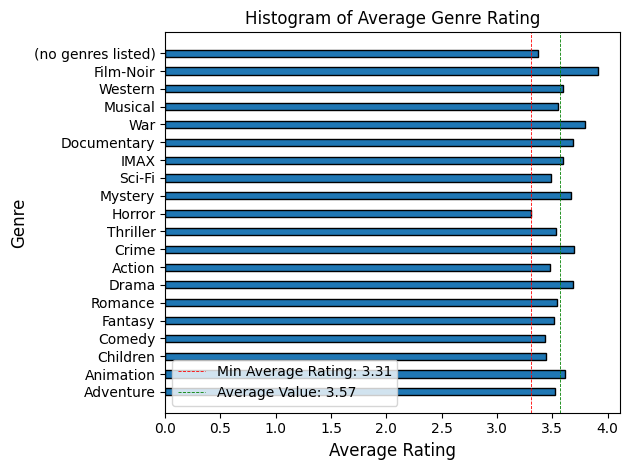

In [17]:
#plotting histogram of genre average rating
plt.barh(genre_axis, genre_rating_axis, height=0.4, edgecolor='black')
plt.title("Histogram of Average Genre Rating", fontsize=12)
plt.ylabel("Genre", fontsize=12)
plt.xlabel("Average Rating", fontsize=12)
plt.xticks(rotation=0)
plt.axvline(x=min(genre_rating_axis), color='red',lw=0.6, linestyle='--', label=f'Min Average Rating: {min(genre_rating_axis):.2f}')
plt.axvline(x=genre_rating_axis.mean(), color='green',lw=0.6, linestyle='--', label=f'Average Value: {genre_rating_axis.mean():.2f}')
plt.legend(loc='lower left')
plt.tight_layout()
plt.savefig(f'drive/MyDrive/ml_scale/results/{SPLIT_STRATEGY}_split/data_exploration/genre_average_rating_{SPLIT_STRATEGY}_split_{DATA_TITLE}_dataset.pdf',format='pdf',dpi=300)
plt.show()

## **4.8 Genre Average Rating Vs Popularity/Degree**

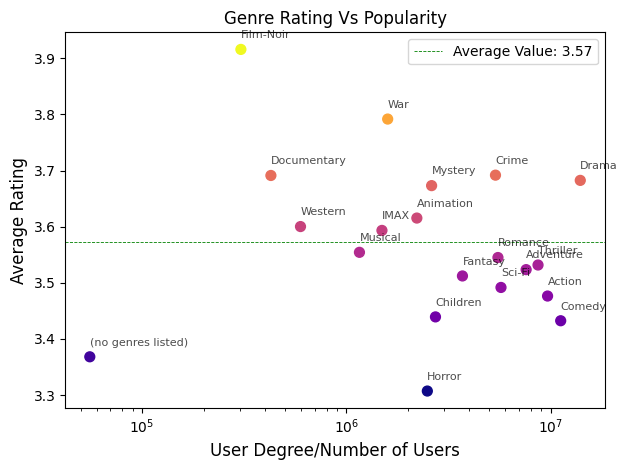

In [18]:
plt.scatter(genre_rating_frequency_axis,genre_rating_axis ,c=genre_rating_axis ,marker='o',cmap='plasma', s=50)
plt.title("Genre Rating Vs Popularity", fontsize=12)
plt.xlabel("User Degree/Number of Users", fontsize=12)
plt.ylabel("Average Rating", fontsize=12)
plt.axhline(y=genre_rating_axis.mean(), color='green',lw=0.6, linestyle='--', label=f'Average Value: {genre_rating_axis.mean():.2f}')
plt.xscale('log')
for x, y, label in zip(genre_rating_frequency_axis, genre_rating_axis, genre_labels):
    plt.text(x+0.02, y+0.02, label, fontsize=8, alpha=0.7)
plt.tight_layout()
plt.legend(loc='upper right')
plt.savefig(f'drive/MyDrive/ml_scale/results/{SPLIT_STRATEGY}_split/data_exploration/genre_av_rating_degree_{SPLIT_STRATEGY}_split_{DATA_TITLE}_dataset.pdf',format='pdf',dpi=300)
plt.show()

## **4.9 Genre Average Rating Vs Movie Degree**

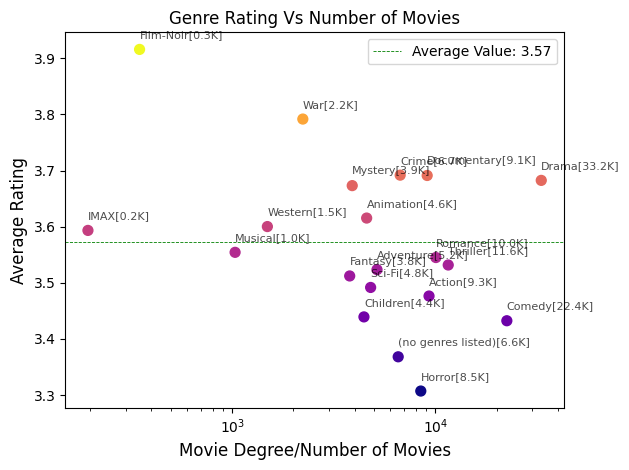

In [19]:
plt.scatter(genre_movie_frequency_axis,genre_rating_axis ,c=genre_rating_axis ,marker='o',cmap='plasma', s=50)
plt.title("Genre Rating Vs Number of Movies", fontsize=12)
plt.xlabel("Movie Degree/Number of Movies", fontsize=12)
plt.ylabel("Average Rating", fontsize=12)
plt.axhline(y=genre_rating_axis.mean(), color='green',lw=0.6, linestyle='--', label=f'Average Value: {genre_rating_axis.mean():.2f}')
plt.xscale('log')
for x, y, label in zip(genre_movie_frequency_axis, genre_rating_axis, genre_labels):
    count=genre_movie_counts[label]
    count_k = count / 1000
    count_str = f"{count_k:.1f}K"

    genre_label=label+f"[{count_str}]"
    plt.text(x+0.02, y+0.02, genre_label, fontsize=8, alpha=0.7)
plt.tight_layout()
plt.legend(loc='upper right')
plt.savefig(f'drive/MyDrive/ml_scale/results/{SPLIT_STRATEGY}_split/data_exploration/genre_av_rating_mov_degree_{SPLIT_STRATEGY}_split_{DATA_TITLE}_dataset.pdf',format='pdf',dpi=300)
plt.show()

## **4.10 Genre Concurrence**

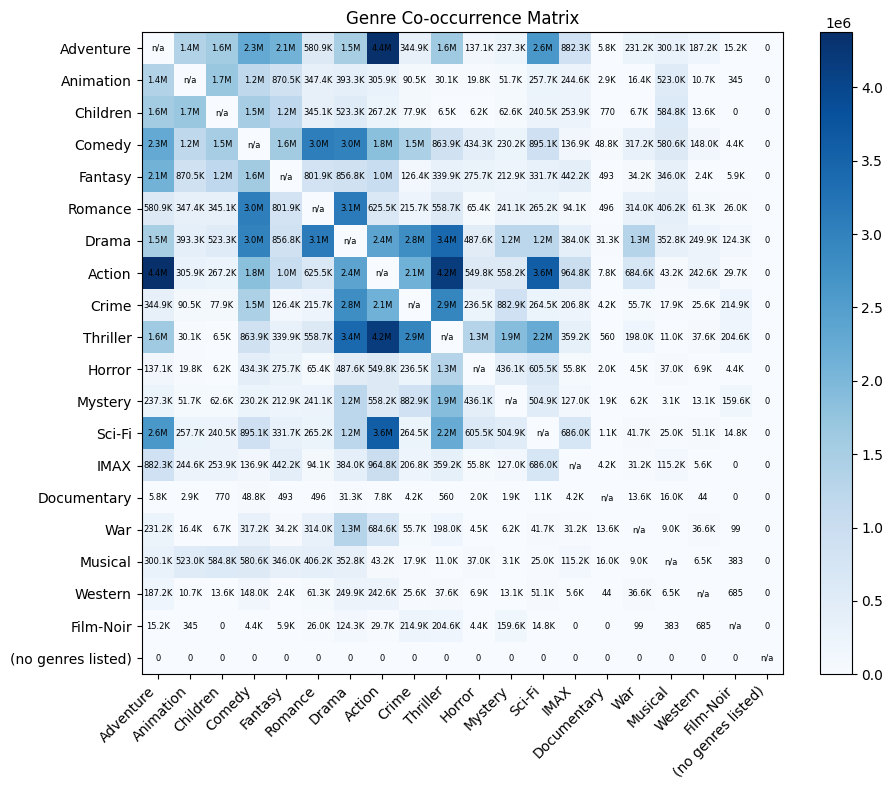

In [20]:


#get list of all genre labels
genre_labels = data_structure.genre_labels
genre_num = len(genre_labels)

genre_labels_lower = [g.lower() for g in genre_labels]

#initializing concurrence matrix
co_currence_matrix = np.zeros((genre_num, genre_num), dtype=int)

#get all user IDs in the dataset
user_ids_train = data_structure.user_id_to_data_idx_train.keys()


#looping through each user 
for user_id in user_ids_train:

    movie_idxs = data_structure.get_ids_vector_by_user(user_id)

    # looping through each movie rated by the user
    for movie_idx in movie_idxs:

        #getting the genre info
        genre_info = data_structure.get_movie_data(movie_idx,use_idx=True)['genre']

        if not genre_info:
            continue

        genre_info = genre_info.lower()

 
        #find genres present in this movie 
        present_indices = [
            i for i, genre in enumerate(genre_labels_lower) if genre in genre_info
        ]


        #counting the concurrences 
        for index in present_indices:
            for index2 in present_indices:
                if index == index2:
                    co_currence_matrix[index, index2] = -1
                else:
                    co_currence_matrix[index, index2] += 1


#plotting the concurrence matrix 
def format_number(x):
    '''This function formats the number x.'''

    if x >= 1_000_000:
        return f"{x/1_000_000:.1f}M"
    elif x >= 100_000_000:
        return f"{x/1_000_000_000:.1f}B"
    elif x >= 1_000:
        return f"{x/1_000:.1f}K"
    elif x < 0:
        return 'n/a'
    else:
        return str(x)

formatted_matrix = np.vectorize(format_number)(co_currence_matrix)

fig, axs = plt.subplots(figsize=(10, 8))
im_data = axs.imshow(co_currence_matrix, cmap='Blues')

for i in range(len(genre_labels)):
    for j in range(len(genre_labels)):
        axs.text(
            j, i,
            formatted_matrix[i, j],
            ha='center',
            va='center',
            color='black',
            fontsize=6
        )

axs.set_xticks(np.arange(genre_num))
axs.set_yticks(np.arange(genre_num))

axs.set_xticklabels(genre_labels, rotation=45, ha='right')
axs.set_yticklabels(genre_labels)

plt.title("Genre Co-occurrence Matrix", fontsize=12)

fig.colorbar(im_data, ax=axs, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.savefig(
    f'drive/MyDrive/ml_scale/results/{SPLIT_STRATEGY}_split/data_exploration/genre_co_currence_{SPLIT_STRATEGY}_split_{DATA_TITLE}_dataset.pdf',
    format='pdf',
    dpi=300
)
plt.show()


# **5.TRAINING WITH BIAS ONLY**


### **5.1 Training loop**

In [21]:
#Training loop: compatible with small data
data=data_structure
#number of users
M = len(data.idx_to_user_id)
#number of movie
N = len(data.idx_to_movie_id)

#initialization
user_biases=np.zeros((M), dtype=np.float64)
item_biases=np.zeros((N), dtype=np.float64)


#lambda
lambda_param=0.1
item_gamma=1e-2
user_gamma=1e-2

#iteractions
epochs=30
#variables to store loss after iteractions
train_nloglikelihood=[]

print('preparing data structures for numba')
time_stamp=datetime.now().timestamp()
#preparing user data for numba parallel processing

user_data = List() #numba list type
for m in range(M):
    n_indice = np.array(data.get_ids_vector_by_user(m, True), dtype=np.int64)
    ratings = np.array(data.get_ratings_vector_by_user(m, True), dtype=np.float64)
    user_data.append((n_indice, ratings))

#Preparing item data (all ratings) for numba parallel processing
item_data = List()
for n in range(N):
    m_indice = np.array(data.get_ids_vector_by_movie(n, True), dtype=np.int64)
    ratings = np.array(data.get_ratings_vector_by_movie(n, True), dtype=np.float64)
    item_data.append((m_indice, ratings))

#Preparing item data (for test loss only)
item_data_test = List()
for n in range(N):
    m_indice = np.array(data.get_ids_vector_by_movie(n, True, is_train=False), dtype=np.int64)
    ratings = np.array(data.get_ratings_vector_by_movie(n, True, is_train=False), dtype=np.float64)
    item_data_test.append((m_indice, ratings))

train_rmse=[]
test_rmse=[]

print('starting training loop')
for epoch in range(epochs):
    Likelihood_train=0

    #updating user biases with parallelization and vectorization
    update_user_biases_only_parallel(user_biases, item_biases, user_data,lambda_param, user_gamma)

    #updating item biases with parallelization and vectorization
    update_item_biases_only_parallel(user_biases, item_biases, item_data,lambda_param, item_gamma)


    #computing RMSE in parallel
    sse_train, count_train, sse_test, count_test = compute_rmse_bias_only_parallel(
        user_biases, item_biases, item_data, item_data_test)

    reg_term=0.5 * user_gamma * (user_biases**2).sum()+0.5 * item_gamma * (item_biases**2).sum()

    Likelihood_train=(0.5*lambda_param)*sse_train+reg_term

    RMSE_train=np.sqrt(sse_train/max(count_train,1))
    RMSE_test=np.sqrt(sse_test/max(count_test,1))


    print_epochs(epoch,epochs,
                  f'#### Epoch: {epoch+1}, Train RMSE: {RMSE_train:.4f}, Test Loss: {RMSE_test:.4f}'
                  ,10)

    train_nloglikelihood.append(Likelihood_train)

    train_rmse.append(RMSE_train)
    test_rmse.append(RMSE_test)
    
time_stamp=datetime.now().timestamp()-time_stamp
#cleaning memory
del item_data
del user_data
del item_data_test
gc.collect()
print('starting training completed...')

print(f'''
#########FINAL RMSE AND NEGATIVE LOSS #####
Train RMSE: {train_rmse[-1]:.04f}
Test RMSE: {test_rmse[-1]:.04f}

Train Negative Loss: {train_nloglikelihood[-1]:.04f}

Duration: {time_stamp:.3f} seconds
###########################################
''')

preparing data structures for numba
starting training loop


/var/autofs/misc/home/vicent/Desktop/ML_Scale/my_recommender_package/ALS_operations.py:24: NumbaTypeSafetyWarning: unsafe cast from uint64 to int64. Precision may be lost.
  n_indice = user_data[m][0]


#### Epoch: 3, Train RMSE: 0.8466, Test Loss: 0.8477
#### Epoch: 6, Train RMSE: 0.8466, Test Loss: 0.8477
#### Epoch: 9, Train RMSE: 0.8466, Test Loss: 0.8477
#### Epoch: 12, Train RMSE: 0.8466, Test Loss: 0.8477
#### Epoch: 15, Train RMSE: 0.8466, Test Loss: 0.8477
#### Epoch: 18, Train RMSE: 0.8466, Test Loss: 0.8477
#### Epoch: 21, Train RMSE: 0.8466, Test Loss: 0.8477
#### Epoch: 24, Train RMSE: 0.8466, Test Loss: 0.8477
#### Epoch: 27, Train RMSE: 0.8466, Test Loss: 0.8477
#### Epoch: 30, Train RMSE: 0.8466, Test Loss: 0.8477
starting training completed...

#########FINAL RMSE AND NEGATIVE LOSS #####
Train RMSE: 0.8466
Test RMSE: 0.8477

Train Negative Loss: 1046428.5908

Duration: 16.483 seconds
###########################################



## **5.2 Plotting RMSE and Loss**


### (i) RMSE

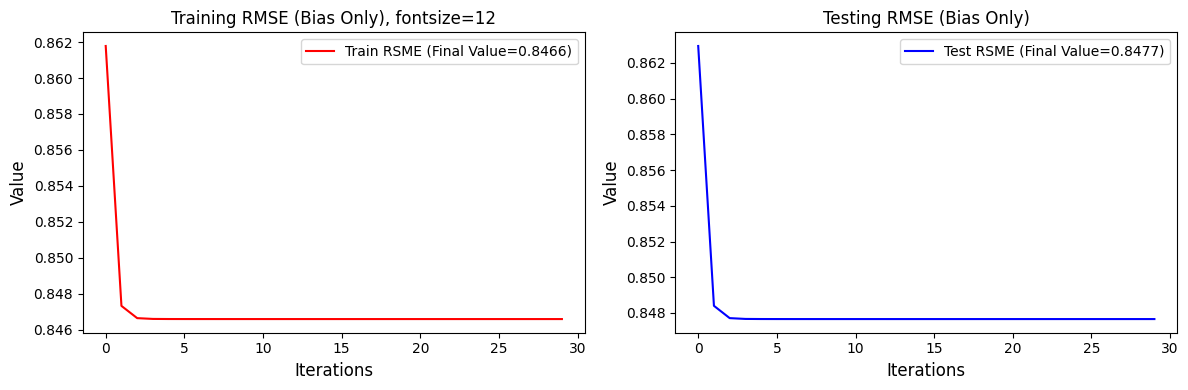

In [22]:
fig, axs = plt.subplots(1, 2, figsize=(12, 4))


axs[0].plot(range(epochs), train_rmse, 'r-', label=f'Train RSME (Final Value={train_rmse[-1]:.4f})')
axs[0].set_title('Training RMSE (Bias Only), fontsize=12')
axs[0].legend(loc='upper right')

axs[1].plot(range(epochs), test_rmse, 'b-',label=f'Test RSME (Final Value={test_rmse[-1]:.4f})')
axs[1].legend(loc='upper right')
axs[1].set_title('Testing RMSE (Bias Only)', fontsize=12)

for ax in axs.flat:
    ax.set_xlabel('Iterations', fontsize=12)
    ax.set_ylabel('Value', fontsize=12)

plt.tight_layout()

plt.savefig(f'drive/MyDrive/ml_scale/results/{SPLIT_STRATEGY}_split/bias_only_rmse_{SPLIT_STRATEGY}_split_{DATA_TITLE}_dataset.pdf',format='pdf',dpi=300)
plt.show()


### (ii) Negative Loss

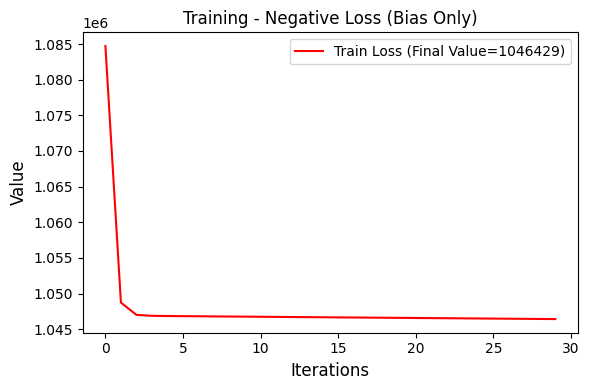

In [23]:
fig, axs = plt.subplots(figsize=(6, 4))

axs.plot(range(epochs), train_nloglikelihood, 'r-',label=f'Train Loss (Final Value={train_nloglikelihood[-1]:.0f})')
axs.set_title('Training - Negative Loss (Bias Only)', fontsize=12)
axs.legend(loc='upper right')

axs.set_xlabel('Iterations', fontsize=12)
axs.set_ylabel('Value', fontsize=12)

plt.tight_layout()

plt.savefig(f'drive/MyDrive/ml_scale/results/{SPLIT_STRATEGY}_split/bias_only_loss_{SPLIT_STRATEGY}_split_{DATA_TITLE}_dataset.pdf',format='pdf',dpi=300)
plt.show()


# **6.TRAINING WITH BIAS AND EMBEDDINGS**

## **6.1 HyperParameter Search, Analysis and Plots**

### **6.1.1 Finding Best Value for Lambda and Tau**

In [24]:
def assign_parameters(model,params,epochs=4):
    model.set_parameters(K=params['k'],tau=params['tau'],gamma=params['gamma'],lambda_param=params['lambda'],epochs=epochs)

In [25]:
#initializing simple model for hyper parameter tunining
my_simple_model=RecommenderModel(data_structure,K=10,tau=1,gamma=1e-2,lambda_param=1,epochs=5,load_avg_genres=False)


In [26]:

parameters={
      "lambda":[0.001,0.1,0.5,1],
      "tau":[0.01,0.1,0.5,1]
}

base_params = {
    "lambda": 0,
    "tau": 0,
    "gamma": 1e-2,
    "k": 10
}
grid_search_results={

}
#implementing grid search for tau and lambda
for lam in parameters["lambda"]:
    for tau in parameters["tau"]:

        params = base_params.copy()
        params["lambda"] = lam
        params["tau"] = tau

        print(f"Training for λ={lam}, τ={tau}")
        print(f"Using parameters: {params}")

        assign_parameters(my_simple_model, params, epochs=5)
        my_simple_model.train()

        key = (lam, tau)
        grid_search_results[key] = {
            'rmse_train': my_simple_model.train_rmse,
            'rmse_test':  my_simple_model.test_rmse,
            'loss_train': my_simple_model.train_nloglikelihood,
            'params': params
        }
#finding the best parameters
final_test_rmse = {
    k: v['rmse_test'][-1] for k, v in grid_search_results.items()
}


Training for λ=0.001, τ=0.01
Using parameters: {'lambda': 0.001, 'tau': 0.01, 'gamma': 0.01, 'k': 10}
Preparing data structures for Numba...
Starting training with Numba parallelization + Vectorized Operations
#### Epoch: 1, Train RMSE: 0.8471, Test RMSE: 0.8490
#### Epoch: 2, Train RMSE: 0.7858, Test RMSE: 0.7887
#### Epoch: 3, Train RMSE: 0.7537, Test RMSE: 0.7569
#### Epoch: 4, Train RMSE: 0.7400, Test RMSE: 0.7434
#### Epoch: 5, Train RMSE: 0.7341, Test RMSE: 0.7374
Training complete!

#########FINAL RMSE AND NEGATIVE LOSS #####
Train RMSE: 0.7341

Test RMSE: 0.7374

Train Negative Loss: 13875.6139

Duration: 37.649 seconds
###########################################

Training for λ=0.001, τ=0.1
Using parameters: {'lambda': 0.001, 'tau': 0.1, 'gamma': 0.01, 'k': 10}
Preparing data structures for Numba...
Starting training with Numba parallelization + Vectorized Operations
#### Epoch: 1, Train RMSE: 0.8763, Test RMSE: 0.8765
#### Epoch: 2, Train RMSE: 0.8162, Test RMSE: 0.8165
#### 

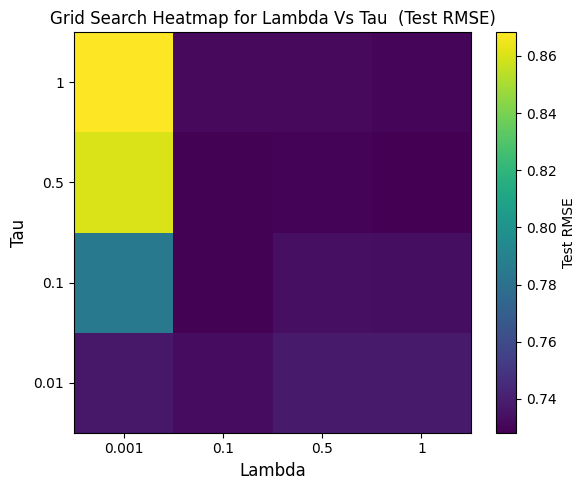

In [27]:
# extract unique sorted values
lambdas = sorted({k[0] for k in grid_search_results.keys()})
taus    = sorted({k[1] for k in grid_search_results.keys()})

# rows = tau, columns = lambda
rmse_matrix = np.zeros((len(taus), len(lambdas)))

for i, tau in enumerate(taus):
    for j, lam in enumerate(lambdas):
        rmse_matrix[i, j] = grid_search_results[(lam, tau)]['rmse_test'][-1]

# plot grid search results for tau and lambda as Heat map
plt.figure(figsize=(6, 5))
im = plt.imshow(rmse_matrix, aspect='auto',origin='lower')
plt.colorbar(im, label='Test RMSE')

plt.xticks(range(len(lambdas)), lambdas)
plt.yticks(range(len(taus)), taus)

plt.xlabel("Lambda", fontsize=12)
plt.ylabel("Tau", fontsize=12)
plt.title("Grid Search Heatmap for Lambda Vs Tau  (Test RMSE)", fontsize=12)

plt.tight_layout()
plt.savefig(f'drive/MyDrive/ml_scale/results/{SPLIT_STRATEGY}_split/tau_lambda_optimization_{SPLIT_STRATEGY}_split_{DATA_TITLE}_dataset.pdf', format='pdf', dpi=300)
plt.show()

In [28]:
#Based on Heat
best_lambda  = 0.1
best_tau  = 1

### **6.1.2 Finding Best Value for K**

In [29]:
gamma=1e-2
k=10
parameters={

      "k":[[1,5,10,15,30,50],{"k":0,"lambda":best_lambda,"gamma":gamma,"tau":best_tau}]
     
}
train_results={

}
for index,param in enumerate(parameters):
     data,params=parameters[param]

     print(f'Training for :{param}')
     #searching through the values for each parameter for best performance
     result={}
     for val in data:
          print(f'#training val: {val}')
          params[param]=val
          print(f"Using parameters:{params}")
          #assigning the value to tested
          assign_parameters(my_simple_model,params,epochs=5)
          #training using value
          my_simple_model.train()
          #storing value
          result[val]={
              'rmse_train':my_simple_model.train_rmse,
              'rmse_test':my_simple_model.test_rmse,
              'loss_train':my_simple_model.train_nloglikelihood,
              'params':params
          }
     
     
     #updating the best result
     vals_train = [result[val]['rmse_train'][-1] for val in result]
     vals_test = [result[val]['rmse_test'][-1]    for val in result]

   
     x = list(result.keys())

     best_index=np.argmin(vals_test)
     best_val = x[best_index]
     print(f"Best value for {param} is {best_val}")
     
     
     
     param_data={
          'result':result,
          'best':best_val,
          'x':x,
          'final_train':vals_train,
          'final_test':vals_test,
          '_config':result[best_val]['params']
     }
     #updating for other parameters
     for index2, other in enumerate(parameters):
           if(param != other and index2 > index):
                 parameters[other][1][param]=best_val
     #saving results
     train_results[param]=param_data


Training for :k
#training val: 1
Using parameters:{'k': 1, 'lambda': 0.1, 'gamma': 0.01, 'tau': 1}
Preparing data structures for Numba...
Starting training with Numba parallelization + Vectorized Operations
#### Epoch: 1, Train RMSE: 0.8635, Test RMSE: 0.8639
#### Epoch: 2, Train RMSE: 0.8395, Test RMSE: 0.8407
#### Epoch: 3, Train RMSE: 0.8273, Test RMSE: 0.8285
#### Epoch: 4, Train RMSE: 0.8187, Test RMSE: 0.8200
#### Epoch: 5, Train RMSE: 0.8149, Test RMSE: 0.8162
Training complete!

#########FINAL RMSE AND NEGATIVE LOSS #####
Train RMSE: 0.8149

Test RMSE: 0.8162

Train Negative Loss: 980703.3449

Duration: 14.453 seconds
###########################################

#training val: 5
Using parameters:{'k': 5, 'lambda': 0.1, 'gamma': 0.01, 'tau': 1}
Preparing data structures for Numba...
Starting training with Numba parallelization + Vectorized Operations
#### Epoch: 1, Train RMSE: 0.8475, Test RMSE: 0.8493
#### Epoch: 2, Train RMSE: 0.8084, Test RMSE: 0.8111
#### Epoch: 3, Train RMS

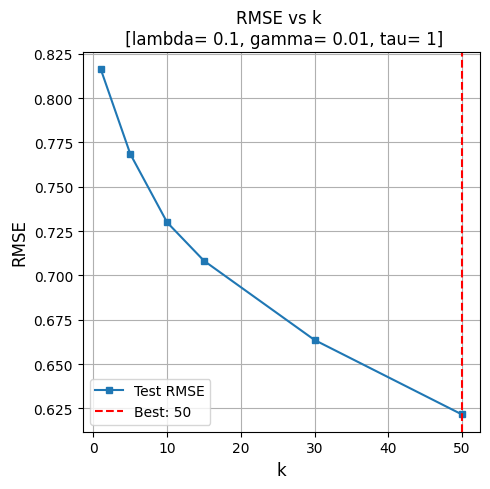

Best parameters are: k=50, gamma=0.01,tau=1,lambda=0.1


In [30]:
num_params = len(train_results)

best_params={}
for index, param in enumerate(train_results):
    plt.figure(figsize=(5, 5))
    results_data = train_results[param]


    x=results_data['x']


    plt.plot(x, results_data['final_test'], marker='s', label='Test RMSE', markersize=5)

    # highlight best test RMSE
    best_val=results_data['best']
    best_params[param]=results_data['best']

    config={k: v for k, v in results_data['_config'].items() if k != param}
    config=str(config).replace('{','[').replace('}',']').replace("'","").replace(":","=")

    plt.axvline(best_val, color='r', linestyle='--', label=f'Best: {best_val}')
    
    plt.title(f"RMSE vs {param} \n {config}", fontsize=12)
    plt.xlabel(param, fontsize=12)
    plt.ylabel('RMSE', fontsize=12)
    plt.legend()
    plt.grid(True)

    # save individual plot
    plt.tight_layout()
    plt.savefig(f'drive/MyDrive/ml_scale/results/{SPLIT_STRATEGY}_split/parameter_optimization_{param}_{SPLIT_STRATEGY}_split_{DATA_TITLE}_dataset.pdf', format='pdf', dpi=300)


plt.show()

print(f'''Best parameters are: k={best_params['k']}, gamma={gamma},tau={best_tau},lambda={best_lambda}''')


## **6.2 Training With No Features**

### **6.2.1 Final Model Instance**

In [31]:
#this model removes the features vectors in the training loop
myModel_nofeatures=RecommenderModel(data_structure,K=15,tau=1,gamma=1e-2,
                         lambda_param=0.1,epochs=30,include_features=False)

### **6.2.2 Model Training**

In [32]:
myModel_nofeatures.train()

Preparing data structures for Numba...
Starting training with Numba parallelization + Vectorized Operations
#### Epoch: 3, Train RMSE: 0.7223, Test RMSE: 0.7284
#### Epoch: 6, Train RMSE: 0.6998, Test RMSE: 0.7058
#### Epoch: 9, Train RMSE: 0.6949, Test RMSE: 0.7006
#### Epoch: 12, Train RMSE: 0.6929, Test RMSE: 0.6986
#### Epoch: 15, Train RMSE: 0.6920, Test RMSE: 0.6976
#### Epoch: 18, Train RMSE: 0.6915, Test RMSE: 0.6970
#### Epoch: 21, Train RMSE: 0.6912, Test RMSE: 0.6967
#### Epoch: 24, Train RMSE: 0.6910, Test RMSE: 0.6964
#### Epoch: 27, Train RMSE: 0.6909, Test RMSE: 0.6963
#### Epoch: 30, Train RMSE: 0.6908, Test RMSE: 0.6961
Training complete!

#########FINAL RMSE AND NEGATIVE LOSS #####
Train RMSE: 0.6908

Test RMSE: 0.6961

Train Negative Loss: 754703.2903

Duration: 134.091 seconds
###########################################

Generating Average Genre Embeddings


### **6.2.3 Plotting Loss**

### (i) RMSE

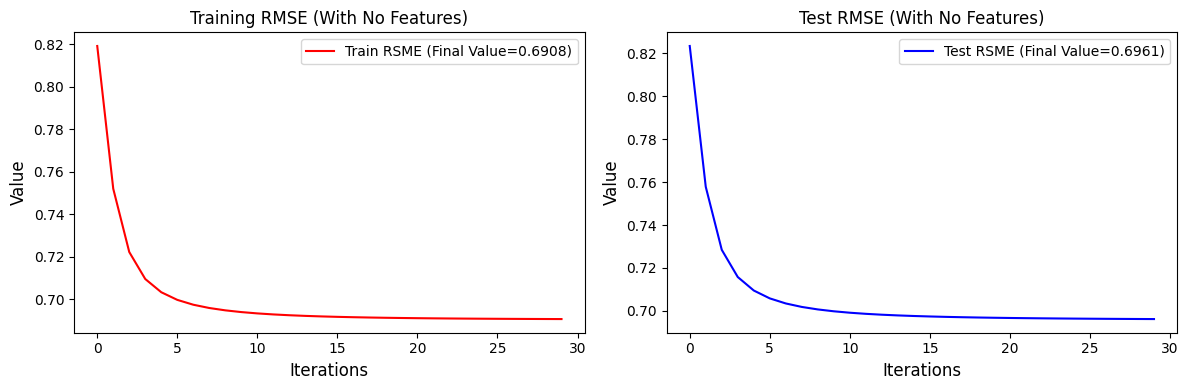

In [33]:
fig, axs = plt.subplots(1, 2, figsize=(12, 4))

axs[0].plot(range(myModel_nofeatures.epochs), myModel_nofeatures.train_rmse, 'r-',label=f'Train RSME (Final Value={myModel_nofeatures.train_rmse[-1]:.4f})')
axs[0].set_title('Training RMSE (With No Features)', fontsize=12)
axs[0].legend(loc='upper right')

axs[1].plot(range(myModel_nofeatures.epochs), myModel_nofeatures.test_rmse, 'b-',label=f'Test RSME (Final Value={myModel_nofeatures.test_rmse[-1]:.4f})')
axs[1].legend(loc='upper right')
axs[1].set_title('Test RMSE (With No Features)', fontsize=12)


for ax in axs.flat:
    ax.set_xlabel('Iterations', fontsize=12)
    ax.set_ylabel('Value', fontsize=12)

plt.tight_layout()
plt.savefig(f'drive/MyDrive/ml_scale/results/{SPLIT_STRATEGY}_split/embedding_and_bias_nofeatures_rmse_{SPLIT_STRATEGY}_split_{DATA_TITLE}_dataset.pdf',format='pdf',dpi=300)
plt.show()



### (ii) Negative Loss

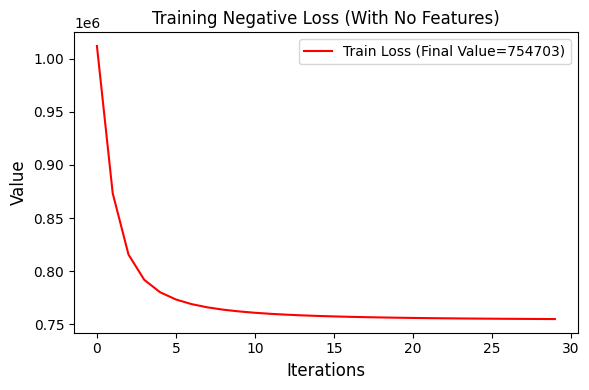

In [34]:
fig, axs = plt.subplots(figsize=(6, 4))

axs.plot(range(myModel_nofeatures.epochs), myModel_nofeatures.train_nloglikelihood, 'r-',label=f'Train Loss (Final Value={myModel_nofeatures.train_nloglikelihood[-1]:.0f})')
axs.set_title('Training Negative Loss (With No Features)', fontsize=12)
axs.legend(loc='upper right')


axs.set_xlabel('Iterations', fontsize=12)
axs.set_ylabel('Value', fontsize=12)

plt.tight_layout()
plt.savefig(f'drive/MyDrive/ml_scale/results/{SPLIT_STRATEGY}_split/embedding_and_bias_nofeatures_loss_{SPLIT_STRATEGY}_split_{DATA_TITLE}_dataset.pdf',format='pdf',dpi=300)
plt.show()


### **6.2.4 Saving Model**

In [35]:
time_stamp = datetime.now().strftime("%Y%m%d")
myModel_nofeatures.save_to_picke_file(f'drive/MyDrive/ml_scale/models/{SPLIT_STRATEGY}_split/model_{time_stamp}_{SPLIT_STRATEGY}_split_{DATA_TITLE}_dataset_nofeatures.pkl')

## **6.3 Training With Features**

### **6.3.1 Final Model Instance**

In [36]:
myModel=RecommenderModel(data_structure,K=15,tau=1,gamma=1e-2, lambda_param=0.1,epochs=30)

### **6.3.2 Model Training**

In [37]:
myModel.train()

Preparing data structures for Numba...
Starting training with Numba parallelization + Vectorized Operations
#### Epoch: 3, Train RMSE: 0.7200, Test RMSE: 0.7259
#### Epoch: 6, Train RMSE: 0.6989, Test RMSE: 0.7047
#### Epoch: 9, Train RMSE: 0.6941, Test RMSE: 0.6997
#### Epoch: 12, Train RMSE: 0.6922, Test RMSE: 0.6976
#### Epoch: 15, Train RMSE: 0.6912, Test RMSE: 0.6964
#### Epoch: 18, Train RMSE: 0.6905, Test RMSE: 0.6956
#### Epoch: 21, Train RMSE: 0.6901, Test RMSE: 0.6951
#### Epoch: 24, Train RMSE: 0.6898, Test RMSE: 0.6947
#### Epoch: 27, Train RMSE: 0.6895, Test RMSE: 0.6944
#### Epoch: 30, Train RMSE: 0.6894, Test RMSE: 0.6941
Training complete!

#########FINAL RMSE AND NEGATIVE LOSS #####
Train RMSE: 0.6894

Test RMSE: 0.6941

Train Negative Loss: 743817.5283

Duration: 147.122 seconds
###########################################

Generating Average Genre Embeddings


### **6.3.3 Plotting Loss**

#### (i) RMSE

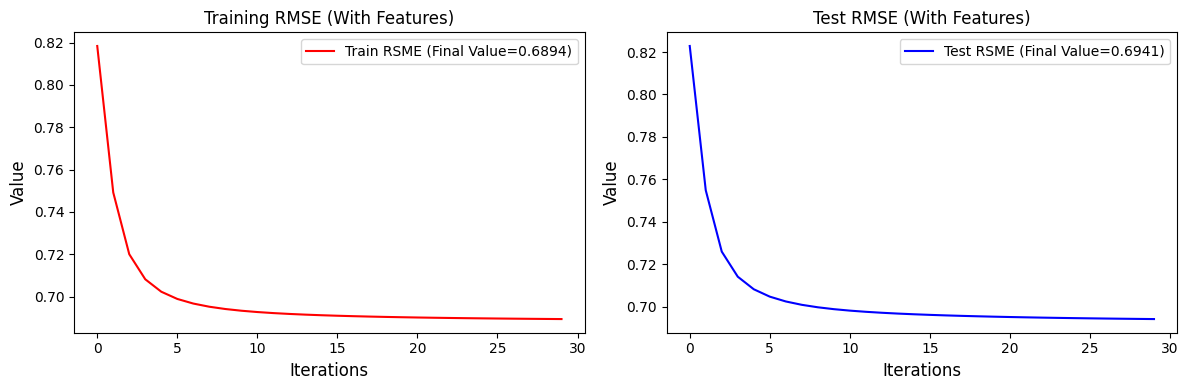

In [38]:
fig, axs = plt.subplots(1, 2, figsize=(12, 4))

axs[0].plot(range(myModel.epochs), myModel.train_rmse, 'r-',label=f'Train RSME (Final Value={myModel.train_rmse[-1]:.4f})')
axs[0].set_title('Training RMSE (With Features)', fontsize=12)
axs[0].legend(loc='upper right')

axs[1].plot(range(myModel.epochs), myModel.test_rmse, 'b-',label=f'Test RSME (Final Value={myModel.test_rmse[-1]:.4f})')
axs[1].legend(loc='upper right')
axs[1].set_title('Test RMSE (With Features)', fontsize=12)


for ax in axs.flat:
    ax.set_xlabel('Iterations', fontsize=12)
    ax.set_ylabel('Value', fontsize=12)

plt.tight_layout()
plt.savefig(f'drive/MyDrive/ml_scale/results/{SPLIT_STRATEGY}_split/embedding_and_bias_withfeatures_rmse_{SPLIT_STRATEGY}_split_{DATA_TITLE}_dataset.pdf',format='pdf',dpi=300)
plt.show()



#### (ii) Negative Loss

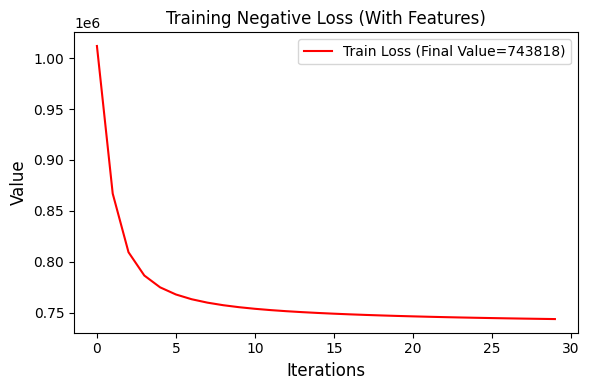

In [39]:
fig, axs = plt.subplots(figsize=(6, 4))

axs.plot(range(myModel.epochs), myModel.train_nloglikelihood, 'r-',label=f'Train Loss (Final Value={myModel.train_nloglikelihood[-1]:.0f})')
axs.set_title('Training Negative Loss (With Features)', fontsize=12)
axs.legend(loc='upper right')


axs.set_xlabel('Iterations', fontsize=12)
axs.set_ylabel('Value', fontsize=12)

plt.tight_layout()
plt.savefig(f'drive/MyDrive/ml_scale/results/{SPLIT_STRATEGY}_split/embedding_and_bias_withfeatures_loss_{SPLIT_STRATEGY}_split_{DATA_TITLE}_dataset.pdf',format='pdf',dpi=300)
plt.show()


### **6.3.4 Plotting Genre Features after Training**

#### **6.3.4.1 Plotting Feature Embeddings and Genres (Based on Average)**

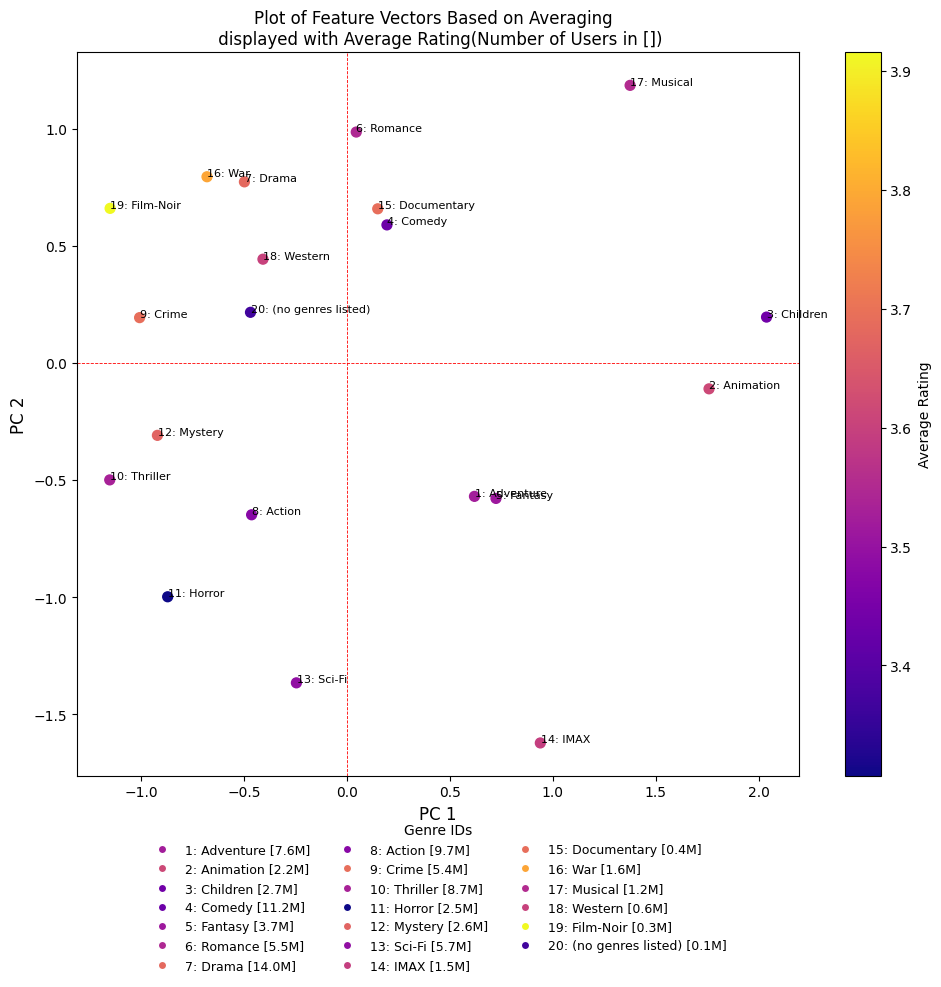

In [40]:
#PLOTTING
genre_embeddings=myModel.avg_genre_embeddings
vectors = np.vstack(list(genre_embeddings.values()))
#reducing the embedding dimensions using PCA
pca = PCA(n_components=2,random_state=SEED)
reduced_genre_avg = pca.fit_transform(vectors)
x_values = reduced_genre_avg [:, 0]
y_values = reduced_genre_avg[:, 1]
labels = list(genre_embeddings.keys())
plt.figure(figsize=(10, 10))
colors=np.array([genre_avg_ratings[label] for label in labels])
scatter=plt.scatter(x_values, y_values,c=colors, cmap='plasma',s=50)

genre_legend_data=[]
for i in range(len(labels)):
    count=genre_counts[labels[i]]
    count_k = count / 1000000
    count_str = f"{count_k:.1f}M"

    genre_label=f"{i+1}: {labels[i]}"+f"[{count_str}]"
    sc_label=f"{i+1}: {labels[i]}"
    genre_legend_data.append(genre_label)
    plt.text(x_values[i] + 0.001, y_values[i] + 0.001, sc_label, fontsize=8)


cbar = plt.colorbar(scatter)
cbar.set_label("Average Rating")
plt.title("Plot of Feature Vectors Based on Averaging  \n displayed with Average Rating(Number of Users in [])", fontsize=12)
plt.xlabel("PC 1", fontsize=12)
plt.ylabel("PC 2", fontsize=12)
plt.axhline(y=0, color='red',lw=0.6, linestyle='--')
plt.axvline(x=0, color='red',lw=0.6, linestyle='--')

#adding legend
cmap = plt.get_cmap('plasma')
norm = plt.Normalize(vmin=min(colors), vmax=max(colors))
legend_handles = [
    Line2D([0], [0],
           marker='o',
           color='w',
           label=f"{i+1}: {labels[i]} [{genre_counts[labels[i]]/1_000_000:.1f}M]",
           markerfacecolor=cmap(norm(colors[i])),
           markersize=6)
    for i in range(len(labels))
]

plt.legend(
    handles=legend_handles,
    fontsize=9,
    title='Genre IDs',
    loc='upper center',
    bbox_to_anchor=(0.5, -0.05),
    ncol=3,
    frameon=False,
)
plt.tight_layout()
plt.savefig(f'drive/MyDrive/ml_scale/results/{SPLIT_STRATEGY}_split/genre_embeddings_{SPLIT_STRATEGY}_split_{DATA_TITLE}_dataset.pdf',format='pdf',dpi=300)
plt.show()


#### **6.3.4.2 Plotting Feature Embeddings and Genres (Based on Training Update)**

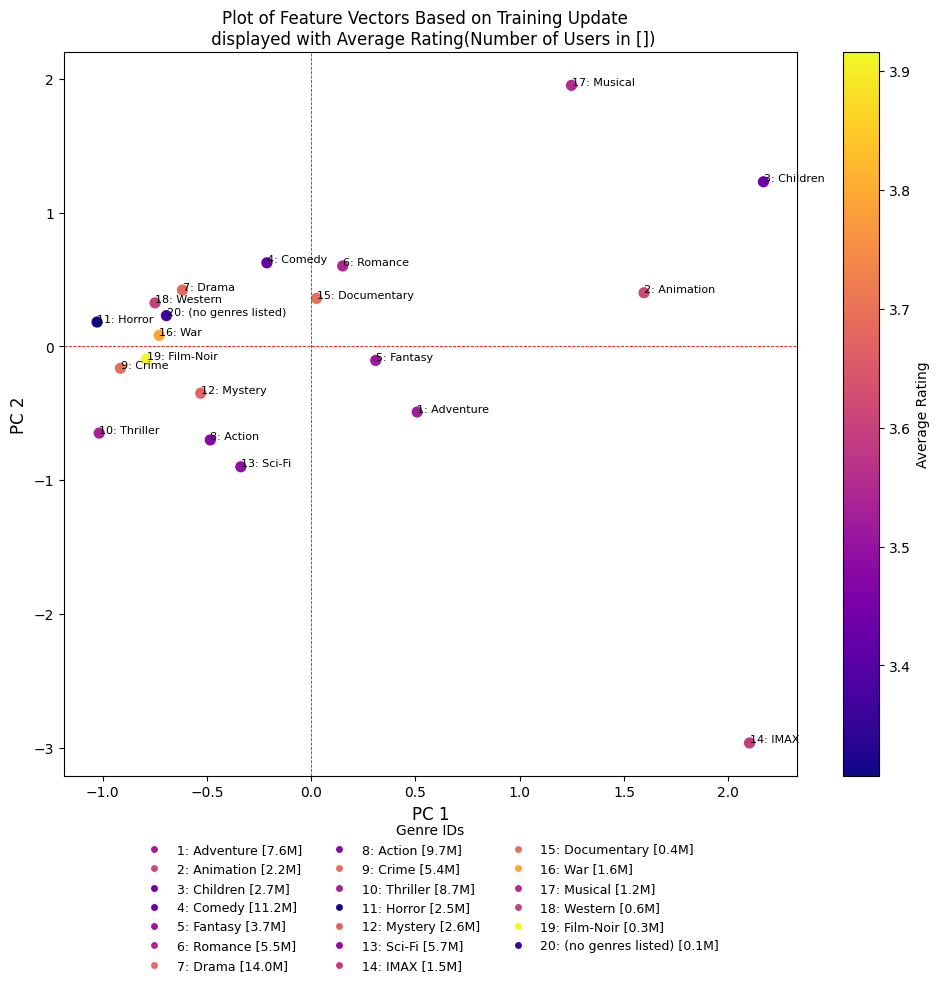

In [41]:
#PLOTTING
genre_embeddings=myModel.F
vectors = np.vstack(list(genre_embeddings))
#reducing the embedding dimensions using PCA
pca = PCA(n_components=2,random_state=SEED)
reduced_genre_updated= pca.fit_transform(vectors)
x_values = reduced_genre_updated[:, 0]
y_values = reduced_genre_updated[:, 1]
labels = list(myModel.genre_labels)
plt.figure(figsize=(10, 10))
colors=np.array([genre_avg_ratings[label] for label in labels])
scatter=plt.scatter(x_values, y_values,c=colors, cmap='plasma',s=50)

genre_legend_data=[]
for i in range(len(labels)):
    count=genre_counts[labels[i]]
    count_k = count / 1000000
    count_str = f"{count_k:.1f}M"

    genre_label=f"{i+1}: {labels[i]}"+f"[{count_str}]"
    sc_label=f"{i+1}: {labels[i]}"
    genre_legend_data.append(genre_label)
    plt.text(x_values[i] + 0.001, y_values[i] + 0.001, sc_label, fontsize=8)


cbar = plt.colorbar(scatter)
cbar.set_label("Average Rating")
plt.title("Plot of Feature Vectors Based on Training Update  \n displayed with Average Rating(Number of Users in [])", fontsize=12)
plt.xlabel("PC 1", fontsize=12)
plt.ylabel("PC 2", fontsize=12)
plt.axhline(y=0, color='red',lw=0.6, linestyle='--')
plt.axvline(x=0, color='red',lw=0.6, linestyle='--')

#adding legend
cmap = plt.get_cmap('plasma')
norm = plt.Normalize(vmin=min(colors), vmax=max(colors))
legend_handles = [
    Line2D([0], [0],
           marker='o',
           color='w',
           label=f"{i+1}: {labels[i]} [{genre_counts[labels[i]]/1_000_000:.1f}M]",
           markerfacecolor=cmap(norm(colors[i])),
           markersize=6)
    for i in range(len(labels))
]

plt.legend(
    handles=legend_handles,
    fontsize=9,
    title='Genre IDs',
    loc='upper center',
    bbox_to_anchor=(0.5, -0.05),
    ncol=3,
    frameon=False,
)
plt.tight_layout()
plt.savefig(f'drive/MyDrive/ml_scale/results/{SPLIT_STRATEGY}_split/genre_embeddings_{SPLIT_STRATEGY}_split_{DATA_TITLE}_trained_dataset.pdf',format='pdf',dpi=300)
plt.show()


#### **6.3.4.3 Plotting Difference Between Features based on Average Vs Features based on Update**

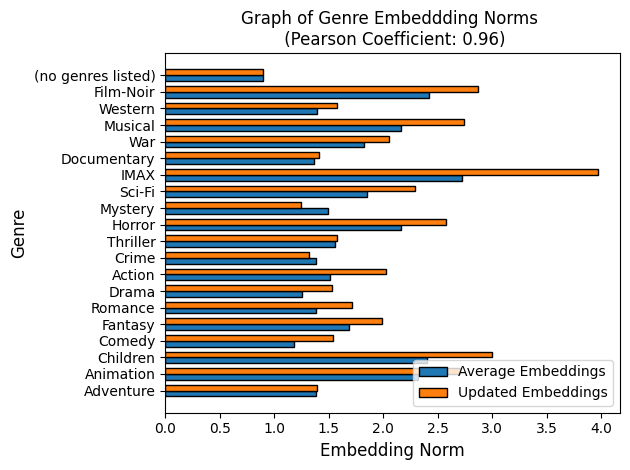

In [42]:
genre_labels = data_structure.genre_labels

avg_vectors= list(myModel.avg_genre_embeddings.values())
updated_vectors= myModel.F
#computing the norms of the vectors
norm_avg = np.linalg.norm(avg_vectors, axis=1)
norm_updated = np.linalg.norm(updated_vectors, axis=1)

#computing the Pearson correlation cofficient
similarity = np.corrcoef(norm_avg, norm_updated)[0,1]



# plotting histogram of genre embeddings similarity
bar_height = 0.35
y = np.arange(len(genre_labels))
plt.barh(y - bar_height / 2, norm_avg, height=bar_height, edgecolor='black',label=f'Average Embeddings')
plt.barh(y + bar_height / 2, norm_updated, height=bar_height, edgecolor='black',label=f'Updated Embeddings')

plt.title(f"Graph of Genre Embeddding Norms \n (Pearson Coefficient: {similarity:.2f})", fontsize=12)
plt.ylabel("Genre", fontsize=12)
plt.yticks(y, genre_labels)
plt.xlabel("Embedding Norm", fontsize=12)
plt.xticks(rotation=0)

plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig(f'drive/MyDrive/ml_scale/results/{SPLIT_STRATEGY}_split/genre_similarity_{SPLIT_STRATEGY}_split_{DATA_TITLE}_dataset.pdf',format='pdf',dpi=300)
plt.show()

### **6.3.5 Movie Embedding Plot**

#### **6.3.5.1 Plotting Movie Trait Vector Space**

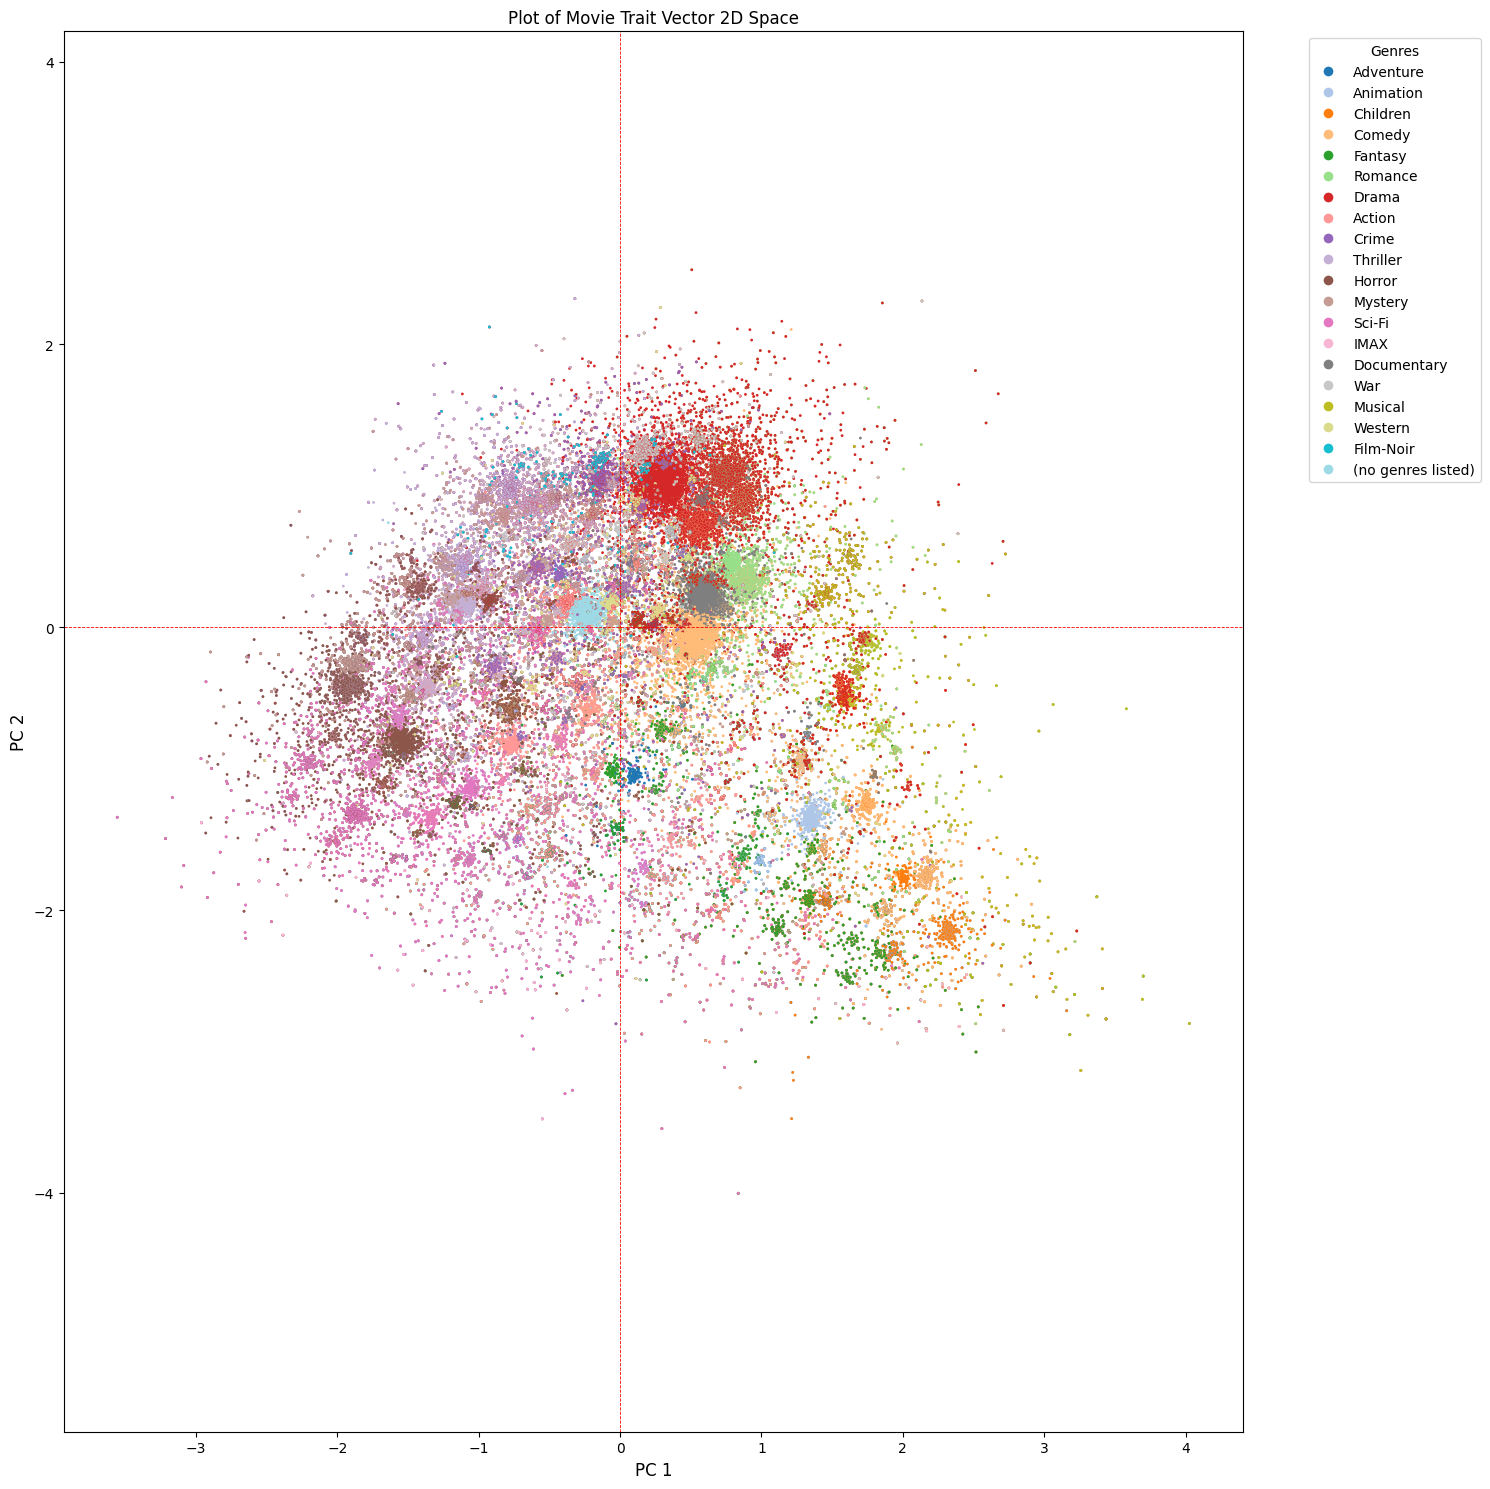

In [43]:

movie_embeddings = myModel.V
genres = myModel.genre_labels

movie_limit = len(movie_embeddings)
genre_count = {g: 0 for g in genres}

movie_embedding_data = []
movie_titles = []
movie_counts = []
genre_labels = []

total_needed = movie_limit * len(genres)
total_added = 0

for n in range(len(movie_embeddings)):
    v = movie_embeddings[n]
    movie_id = data_structure.idx_to_movie_id[n]
    details = data_structure.get_movie_data(movie_id)

    movie_genre_list = details['genre']
    movie_title = details['title']

    # Add movie if it belongs to a genre and limit not exceeded
    for g in genres:
        if g in movie_genre_list and genre_count[g] < movie_limit:
            genre_count[g] += 1

            movie_embedding_data.append(v)
            movie_titles.append(movie_title)
            genre_labels.append(g)

            data = data_structure.get_data_by_movie_id(movie_id)
            movie_counts.append(len(data))

            total_added += 1

    if total_added >= total_needed:
        break

#PCA
vectors = np.vstack(movie_embedding_data)
#reducing the embedding dimensions using PCA
pca = PCA(n_components=2,random_state=SEED)
reduced = pca.fit_transform(vectors)
x = reduced[:, 0]
y = reduced[:, 1]

#genre colors
genre_to_id = {g: i for i, g in enumerate(genres)}
numeric_colors = np.array([genre_to_id[g] for g in genre_labels])

#plot
plt.figure(figsize=(15, 15))
scatter = plt.scatter(x, y, c=numeric_colors, cmap='tab20', s=1, rasterized=True)


plt.title("Plot of Movie Trait Vector 2D Space", fontsize=12)
plt.xlabel("PC 1", fontsize=12)
plt.ylabel("PC 2", fontsize=12)
plt.axhline(0, color='red', lw=0.6, linestyle='--')
plt.axvline(0, color='red', lw=0.6, linestyle='--')
plt.axis('equal')

#legend
handles = [
    plt.Line2D([0], [0], marker='o', color='w', label=g,
               markerfacecolor=plt.cm.tab20(genre_to_id[g] / len(genres)),
               markersize=8)
    for g in genres
]
plt.legend(handles=handles, title="Genres", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.savefig(f'drive/MyDrive/ml_scale/results/{SPLIT_STRATEGY}_split/all_movie_embeddings_plot_{SPLIT_STRATEGY}_split_{DATA_TITLE}_dataset.pdf', format='pdf', dpi=150)
plt.show()

#### **6.3.5.2 Plotting Sample of Movie Trait Vectors**

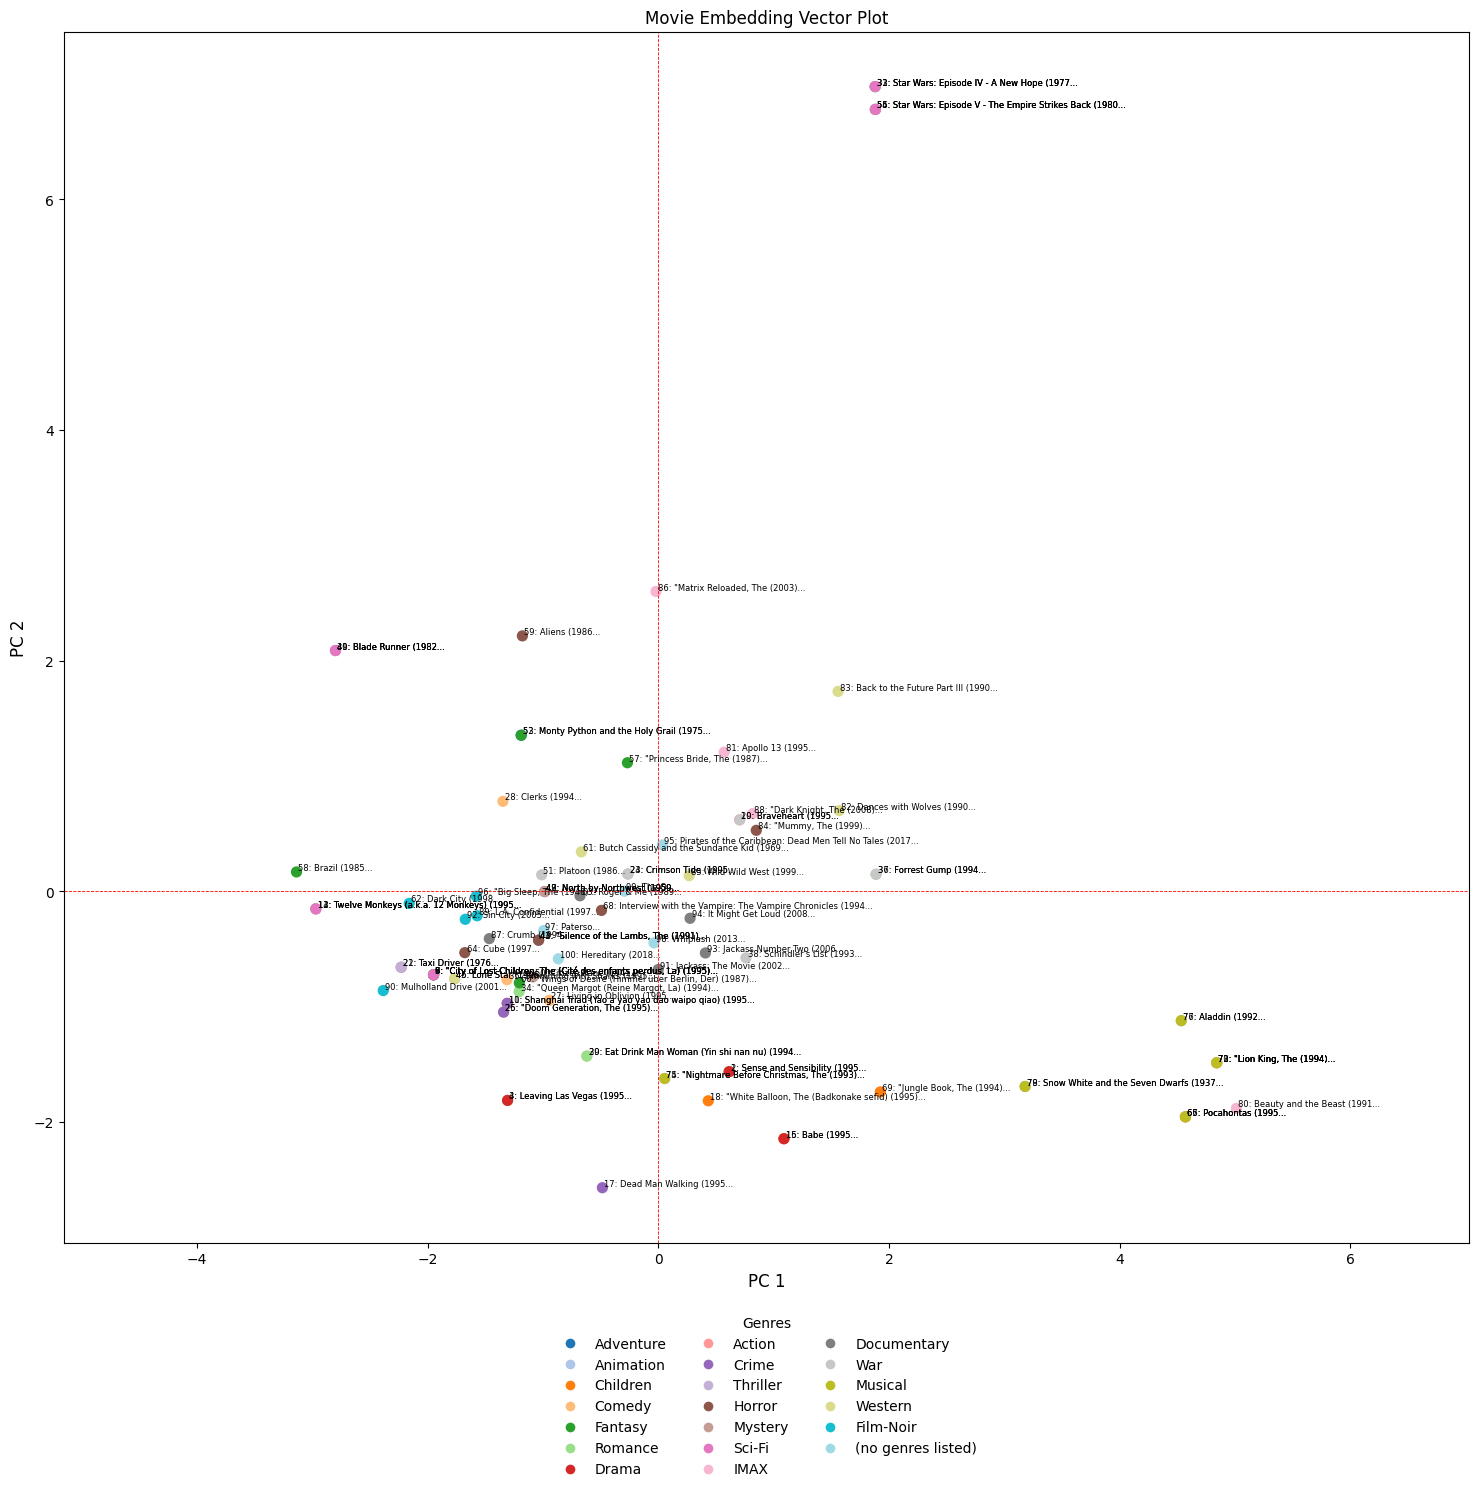

In [44]:
movie_embeddings = myModel.V
genres = myModel.genre_labels

# Track how many movies per genre we have added
movie_limit = 5
genre_count = {g: 0 for g in genres}

movie_embedding_data = []
movie_titles = []
movie_counts = []
genre_labels = []

total_needed = movie_limit * len(genres)
total_added = 0

for n in range(len(movie_embeddings)):
    v = movie_embeddings[n]
    movie_id = data_structure.idx_to_movie_id[n]
    details = data_structure.get_movie_data(movie_id)

    movie_genre_list = details['genre']
    movie_title = details['title']

    # Add movie if it belongs to a genre and limit not exceeded
    for g in genres:
        if g in movie_genre_list and genre_count[g] < movie_limit:
            genre_count[g] += 1

            movie_embedding_data.append(v)
            movie_titles.append(movie_title)
            genre_labels.append(g)

            data = data_structure.get_data_by_movie_id(movie_id)
            movie_counts.append(len(data))

            total_added += 1
            

    if total_added >= total_needed:
        break

#PCA
vectors = np.vstack(movie_embedding_data)
#reducing the embedding dimensions using PCA
pca = PCA(n_components=2,random_state=SEED)
reduced = pca.fit_transform(vectors)
x = reduced[:, 0]
y = reduced[:, 1]

#genre colors
genre_to_id = {g: i for i, g in enumerate(genres)}
numeric_colors = np.array([genre_to_id[g] for g in genre_labels])

#plot
plt.figure(figsize=(15, 15))
scatter = plt.scatter(x, y, c=numeric_colors, cmap='tab20', s=50)
title_length=-1
#labels
for i, title in enumerate(movie_titles):
    sc_label = f"{i+1}: {title[:title_length]}..."
    plt.text(x[i]+0.015, y[i]+0.015, sc_label, fontsize=6)

plt.title("Movie Embedding Vector Plot", fontsize=12)
plt.xlabel("PC 1", fontsize=12)
plt.ylabel("PC 2", fontsize=12)
plt.axhline(0, color='red', lw=0.6, linestyle='--')
plt.axvline(0, color='red', lw=0.6, linestyle='--')
plt.axis('equal')

#legend
handles = [
    plt.Line2D([0], [0], marker='o', color='w', label=g,
               markerfacecolor=plt.cm.tab20(genre_to_id[g] / len(genres)),
               markersize=8)
    for g in genres
]
plt.legend(
    handles=handles, 
    title="Genres", 
    loc='upper center',
    bbox_to_anchor=(0.5, -0.05),
    ncol=3,
    frameon=False,
    )

plt.tight_layout()
plt.savefig(f'drive/MyDrive/ml_scale/results/{SPLIT_STRATEGY}_split/movie_embeddings_plot_{SPLIT_STRATEGY}_split_{DATA_TITLE}_dataset.pdf', format='pdf', dpi=300)
plt.show()


#### **6.3.5.3 Finding Polarizing Movies**

##### **(i) Most Polarizing Movies**

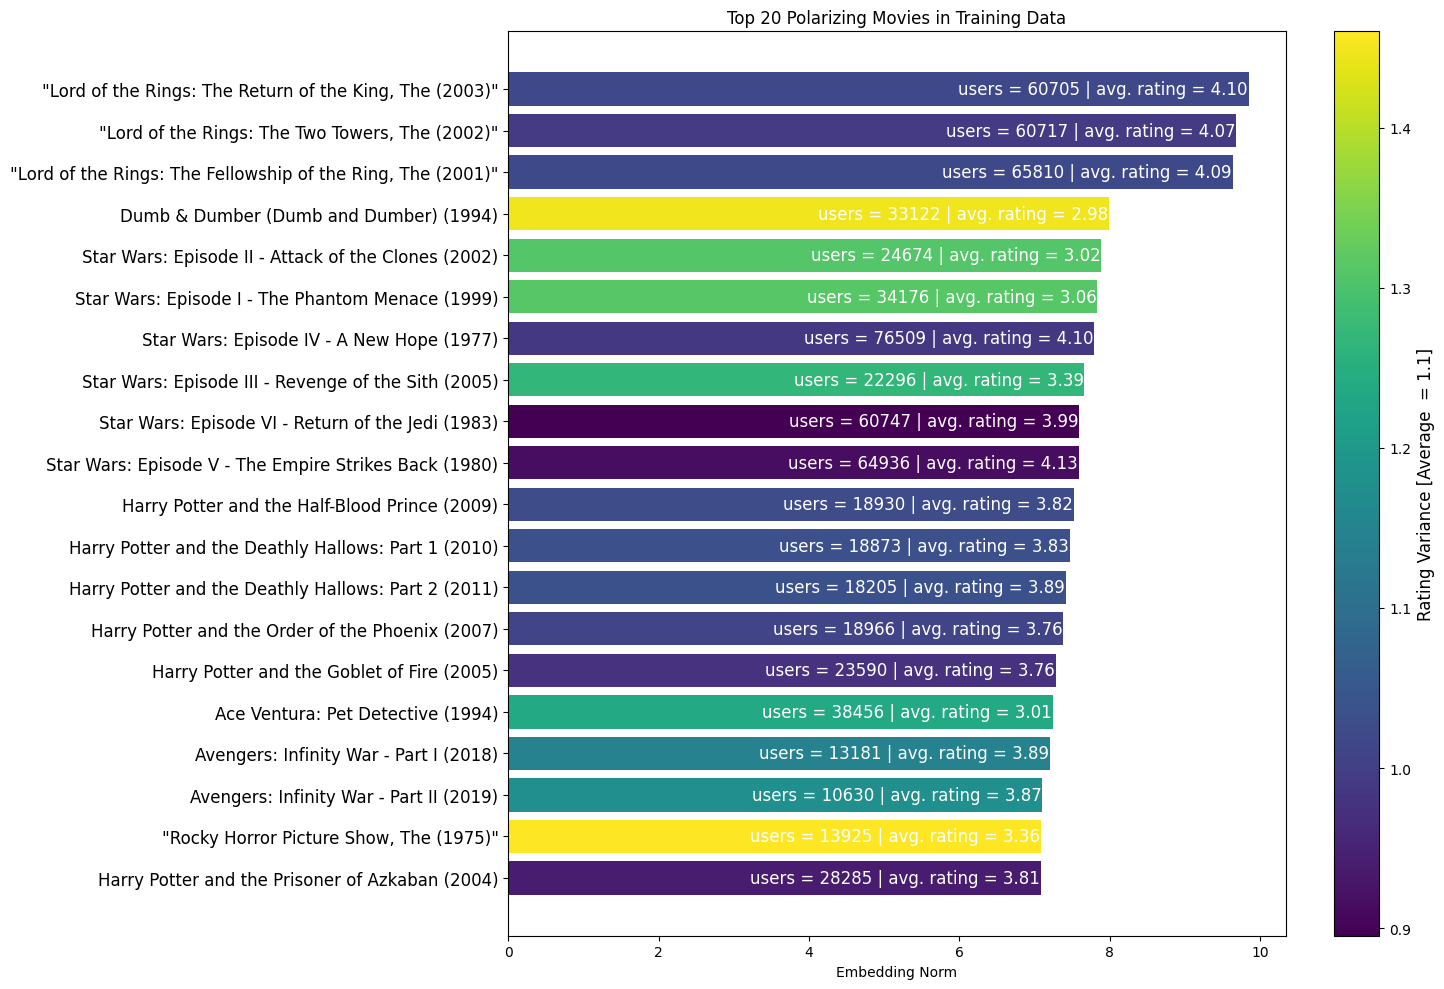

In [45]:
movie_embeddings = myModel.V

ratings = [data_structure.get_data_by_movie_train(idx, use_idx=True) for idx in range(len(movie_embeddings))]
ratings = np.array(ratings, dtype=object) 

ids = [data_structure.idx_to_movie_id[idx] for idx in range(len(movie_embeddings))]
ids = np.array(ids)

#filtering the movies with few users
num_filter = 100
filtered_indices = [i for i, r in enumerate(ratings) if len(r) >= num_filter]

ids=ids[filtered_indices]
movie_embeddings=movie_embeddings[filtered_indices]
ratings = ratings[filtered_indices]

norms = np.linalg.norm(movie_embeddings, axis=1)

# number of top polarizing movies to show
limit = 20
# get sorting indices 
indices = np.argsort(norms)[::-1]
sorted_indices = indices[:limit]

# sort all arrays 
sorted_norms = norms[sorted_indices]
sorted_norms_vals = [norm for norm in sorted_norms]

pos = [i+1 for i in range(len(sorted_norms))]
movie_ids = [ids[idx] for idx in sorted_indices]

top_polarized = [ids[idx] for idx in indices[:100]]

movie_titles = [data_structure.get_movie_data(id)['title'] for id in movie_ids]
movie_genres = [data_structure.get_movie_data(id)['genre'] for id in movie_ids]
movie_ratings = [ratings[idx] for idx in sorted_indices]
movie_ratings_avg = [np.mean(ratings) for ratings in movie_ratings]
movie_ratings_var = [np.var(ratings) for ratings in movie_ratings]
movie_users = [len(ratings) for ratings in movie_ratings]

#convert rating variance to a color scale
variance_array = np.array(movie_ratings_var)
colors = plt.cm.viridis((variance_array - variance_array.min()) / 
                        (variance_array.max() - variance_array.min()))

# plotting  bar graph
fig, ax = plt.subplots(figsize=(15, 10)) 
y_pos = np.arange(len(movie_titles))

bars = ax.barh(y_pos, sorted_norms_vals, color=colors)

ax.set_yticks(y_pos)
ax.set_yticklabels([t if len(t)<=100 else t[:50]+'...' for t in movie_titles], fontsize=12)

ax.set_xlabel("Embedding Norm", fontsize=10)
ax.set_title(f"Top {limit} Polarizing Movies in Training Data", fontsize=12)

# invert y-axis so top movie is on top
ax.invert_yaxis()

# add text on bars
for i, bar in enumerate(bars):
    width = bar.get_width()
    ax.text(width - 0.01, bar.get_y() + bar.get_height()/2,
            f"users = {movie_users[i]} | avg. rating = {movie_ratings_avg[i]:.2f}",
            va='center', ha='right', fontsize=12, color='white')

# add colorbar for rating variance
sm = plt.cm.ScalarMappable(cmap='viridis', 
                           norm=plt.Normalize(vmin=variance_array.min(), vmax=variance_array.max()))
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax)
cbar.set_label(f'Rating Variance [Average  = {np.mean(variance_array):.1f}]', fontsize=12)

plt.tight_layout()
plt.savefig(
    f'drive/MyDrive/ml_scale/results/{SPLIT_STRATEGY}_split/'
    f'most_polarizing_movies_{SPLIT_STRATEGY}_split_{DATA_TITLE}_dataset.pdf',
    format='pdf',
    dpi=300
)
plt.show()


##### **(ii) Least Polarizing Movies**

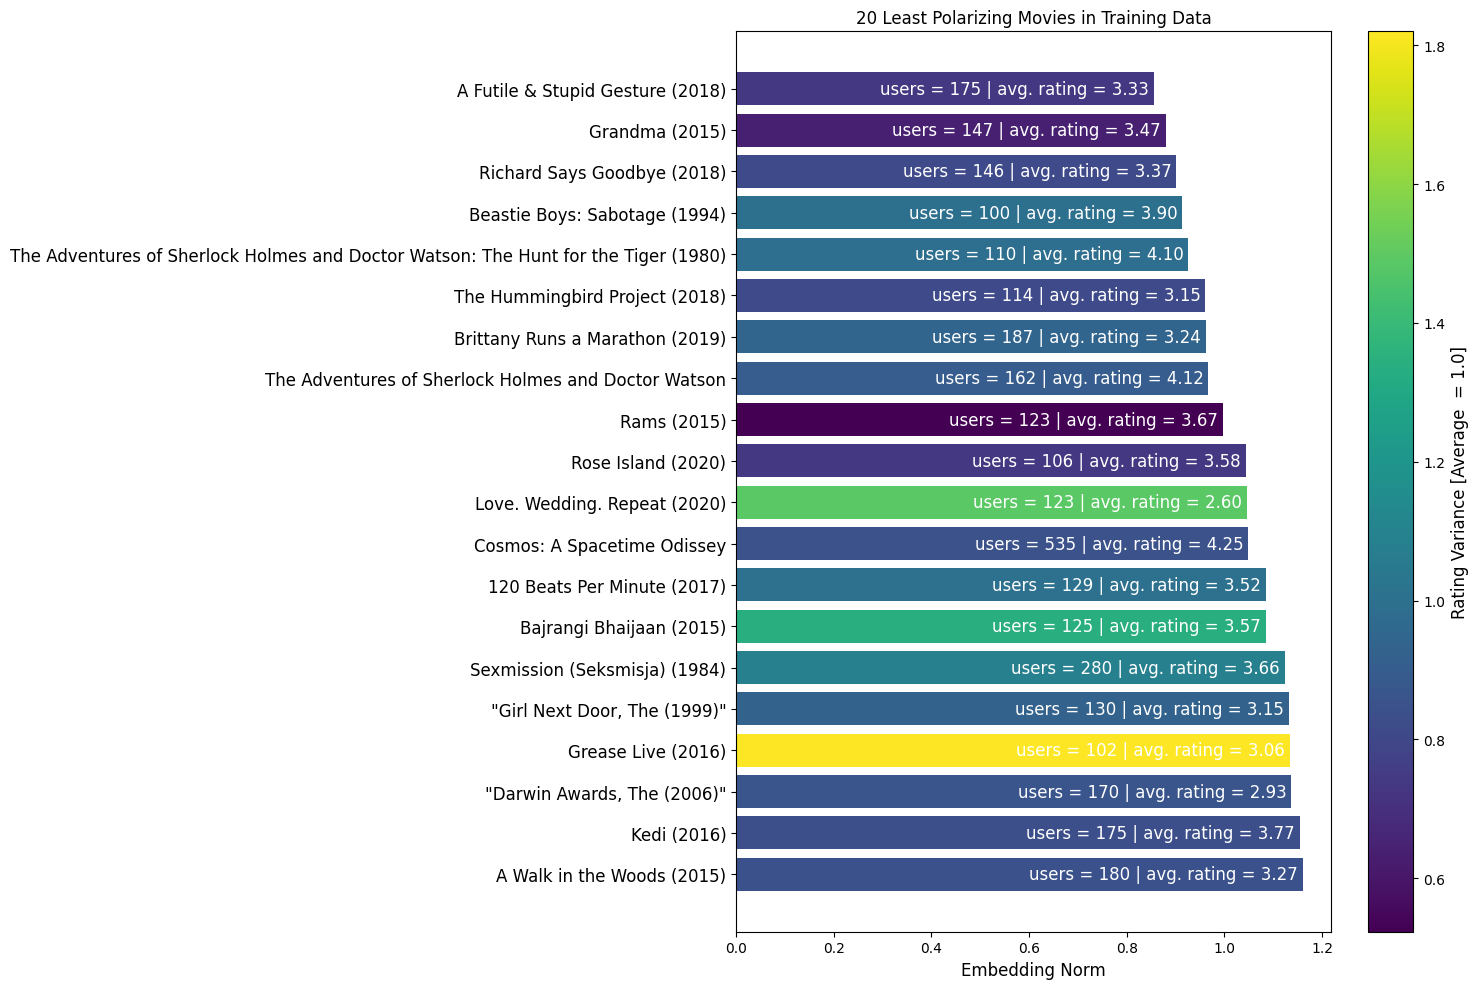

In [46]:
movie_embeddings = myModel.V

ratings = [data_structure.get_data_by_movie_train(idx, use_idx=True) for idx in range(len(movie_embeddings))]
ratings = np.array(ratings, dtype=object) 

ids = [data_structure.idx_to_movie_id[idx] for idx in range(len(movie_embeddings))]
ids = np.array(ids)

#filtering the movies with few users
num_filter = 100
filtered_indices = [i for i, r in enumerate(ratings) if len(r) >= num_filter]

ids=ids[filtered_indices]
movie_embeddings=movie_embeddings[filtered_indices]
ratings = ratings[filtered_indices]

norms = np.linalg.norm(movie_embeddings, axis=1)

# number of least polarizing movies to show
limit = 20
# get sorting indices 
indices = np.argsort(norms)
sorted_indices = indices[:limit]

# sort all arrays 
sorted_norms = norms[sorted_indices]
sorted_norms_vals = [norm for norm in sorted_norms]

pos = [i+1 for i in range(len(sorted_norms))]
movie_ids = [ids[idx] for idx in sorted_indices]

least_polarized = movie_ids

movie_titles = [data_structure.get_movie_data(id)['title'] for id in movie_ids]
movie_genres = [data_structure.get_movie_data(id)['genre'] for id in movie_ids]
movie_ratings = [ratings[idx] for idx in sorted_indices]
movie_ratings_avg = [np.mean(ratings) for ratings in movie_ratings]
movie_ratings_var = [np.var(ratings)  for ratings in movie_ratings]
movie_users = [len(ratings) for ratings in movie_ratings]

#convert rating variance to a color scale
variance_array = np.array(movie_ratings_var)
colors = plt.cm.viridis((variance_array - variance_array.min()) / 
                        (variance_array.max() - variance_array.min()))

# plotting  bar graph
fig, ax = plt.subplots(figsize=(15, 10)) 
y_pos = np.arange(len(movie_titles))

bars = ax.barh(y_pos, sorted_norms_vals, color=colors)

ax.set_yticks(y_pos)
ax.set_yticklabels([t if len(t)<=100 else t[:50]+'...' for t in movie_titles], fontsize=12)

ax.set_xlabel("Embedding Norm", fontsize=12)
ax.set_title(f"{limit} Least Polarizing Movies in Training Data", fontsize=12)

ax.invert_yaxis()

# add text on bars
for i, bar in enumerate(bars):
    width = bar.get_width()
    ax.text(width - 0.01, bar.get_y() + bar.get_height()/2,
            f"users = {movie_users[i]} | avg. rating = {movie_ratings_avg[i]:.2f}",
            va='center', ha='right', fontsize=12, color='white')

# add colorbar for rating variance
sm = plt.cm.ScalarMappable(cmap='viridis', 
                           norm=plt.Normalize(vmin=variance_array.min(), vmax=variance_array.max()))
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax)
cbar.set_label(f'Rating Variance [Average  = {np.mean(variance_array):.1f}]', fontsize=12)

plt.tight_layout()
plt.savefig(
    f'drive/MyDrive/ml_scale/results/{SPLIT_STRATEGY}_split/least_polarizing_movies_{SPLIT_STRATEGY}_split_{DATA_TITLE}_dataset.pdf',
    format='pdf',
    dpi=300)
plt.show()


#### (iii) Updating Model for Polarizing Items

In [47]:
# updating the polarzing list to help the model filter for these items
myModel.polarized = top_polarized 

###  **6.3.6 Saving the Model**

In [48]:
time_stamp = datetime.now().strftime("%Y%m%d")
myModel.save_to_picke_file(f'drive/MyDrive/ml_scale/models/{SPLIT_STRATEGY}_split/model_{time_stamp}_{SPLIT_STRATEGY}_split_{DATA_TITLE}_dataset_withfeatures.pkl')

### **6.3.6 Loading Saved Model**

In [49]:
time_stamp = datetime.now().strftime("%Y%m%d")
myModel_saved=myModel.load_from_pickle_file(f'drive/MyDrive/ml_scale/models/{SPLIT_STRATEGY}_split/model_{time_stamp}_{SPLIT_STRATEGY}_split_{DATA_TITLE}_dataset_withfeatures.pkl',data_struct=data_structure)

#  **7.PREDICTION**

USER CHOICES
=== 1. Finding Nemo (2003)  ===
Movie ID: 6377
User Rank: 3.8165
Genres: Adventure|Animation|Children|Comedy
Url: http://www.imdb.com/title/tt0266543/


Predicted ratings stats:
  Min: -0.2399
  Max: 0.3884
  Mean: -0.0247
  Std: 0.0595
  Movies considered: 84432

=== 1. Toy Story 3 (2010)  ===
Movie ID: 78499
Model Score: 0.3884
Rank: 5.00
Genres: Adventure|Animation|Children|Comedy|Fantasy|IMAX
Url: http://www.imdb.com/title/tt0435761/

=== 2. Toy Story 2 (1999)  ===
Movie ID: 3114
Model Score: 0.3866
Rank: 4.99
Genres: Adventure|Animation|Children|Comedy|Fantasy
Url: http://www.imdb.com/title/tt0120363/

=== 3. Toy Story (1995)  ===
Movie ID: 1
Model Score: 0.3789
Rank: 4.93
Genres: Adventure|Animation|Children|Comedy|Fantasy
Url: http://www.imdb.com/title/tt0114709/

=== 4. "Monsters, Inc. (2001)"  ===
Movie ID: 4886
Model Score: 0.3777
Rank: 4.92
Genres: Adventure|Animation|Children|Comedy|Fantasy
Url: http://www.imdb.com/title/tt0198781/

=== 5. "Incredibles, The (20

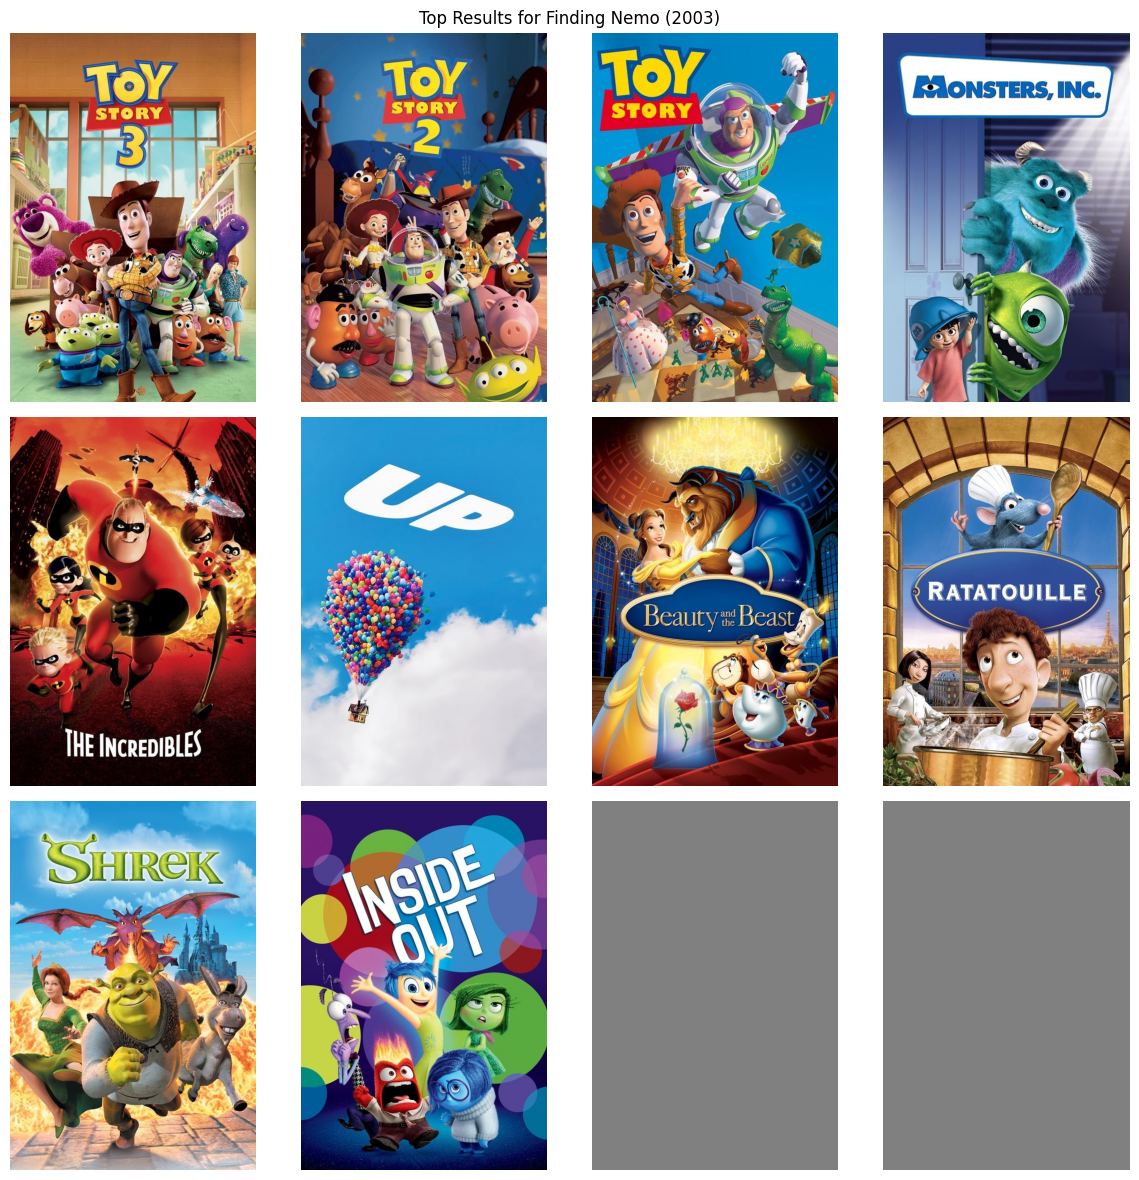

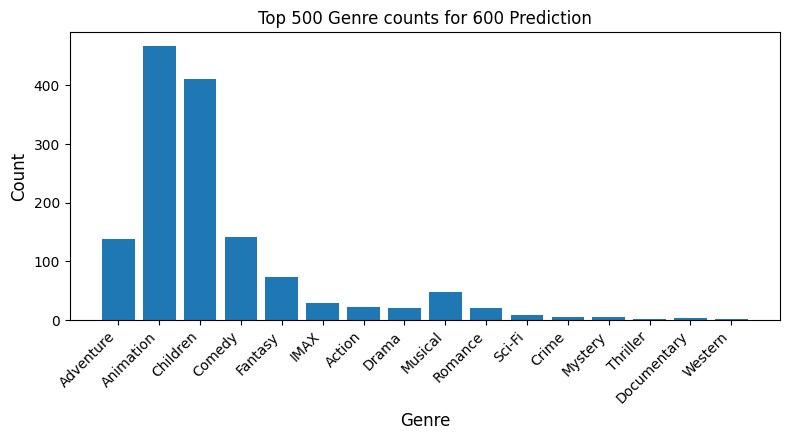

In [51]:
#Test movie ID: 6377 - Finding Nemo, 6874 - Kill Bill: Vol. 1 
#Creating data for the dummy user
dummy_user_ratings=[
    [data_structure.movie_id_to_idx[6377], 5],

]
#getting meta about dummay user data
choice=get_movie_data(data_structure,dummy_user_ratings,add_data_rating=True)

print("USER CHOICES")
print_selection(choice,True)

genres=[]
selection=myModel_saved.predict(dummy_user_ratings,10,show_stats=True)
#printing results 
print_selection(selection)

print_selection_summary_latex(selection)

#displaying movie posters
search_title = f"Top Results for {', '.join(r['title'] for r in choice)}"
generate_movie_grid(data_structure,selection,search_title=search_title,title='dummy_user_pred', data_title=DATA_TITLE, split_strategy=SPLIT_STRATEGY)

for i in range(1):
    selection=myModel_saved.predict(dummy_user_ratings,500)

    for m in selection:
          genres.append(m['genre'])

#plotting histogram of genres in top 500 results in prediction
plot_genres(genres,top=500, title="prediction_stats",search = f'for {str(dummy_user_ratings[0][0])} Prediction', data_title=DATA_TITLE, split_strategy=SPLIT_STRATEGY)



# **8.GENRE BASED PREDICTION (USING FEATURE EMBEDDINGS)**

USER CHOICES
GENRE: RATING
Documentary: 5

Predicted ratings stats:
  Min: -0.2393
  Max: 0.2654
  Mean: 0.0007
  Std: 0.0604
  Movies considered: 84432

=== 1. Destination: Pluto Beyond the Flyby (2016)  ===
Movie ID: 216789
Model Score: 0.2654
Rank: 5.00
Genres: Documentary
Url: http://www.imdb.com/title/tt6975082/

=== 2. A Dramatic Film (2019)  ===
Movie ID: 235787
Model Score: 0.2158
Rank: 4.56
Genres: Documentary
Url: http://www.imdb.com/title/tt10793640/

=== 3. The United States of Insanity (2021)  ===
Movie ID: 268552
Model Score: 0.2149
Rank: 4.55
Genres: Documentary
Url: http://www.imdb.com/title/tt8356450/

=== 4. "Hare Krishna! The Mantra, the Movement and the Swami Who Started It All (2017)"  ===
Movie ID: 207696
Model Score: 0.2042
Rank: 4.45
Genres: Documentary
Url: http://www.imdb.com/title/tt6842524/

=== 5. 1964: Brazil Between Weapons and Books (2019)  ===
Movie ID: 225429
Model Score: 0.1998
Rank: 4.41
Genres: Documentary
Url: http://www.imdb.com/title/tt10135068/


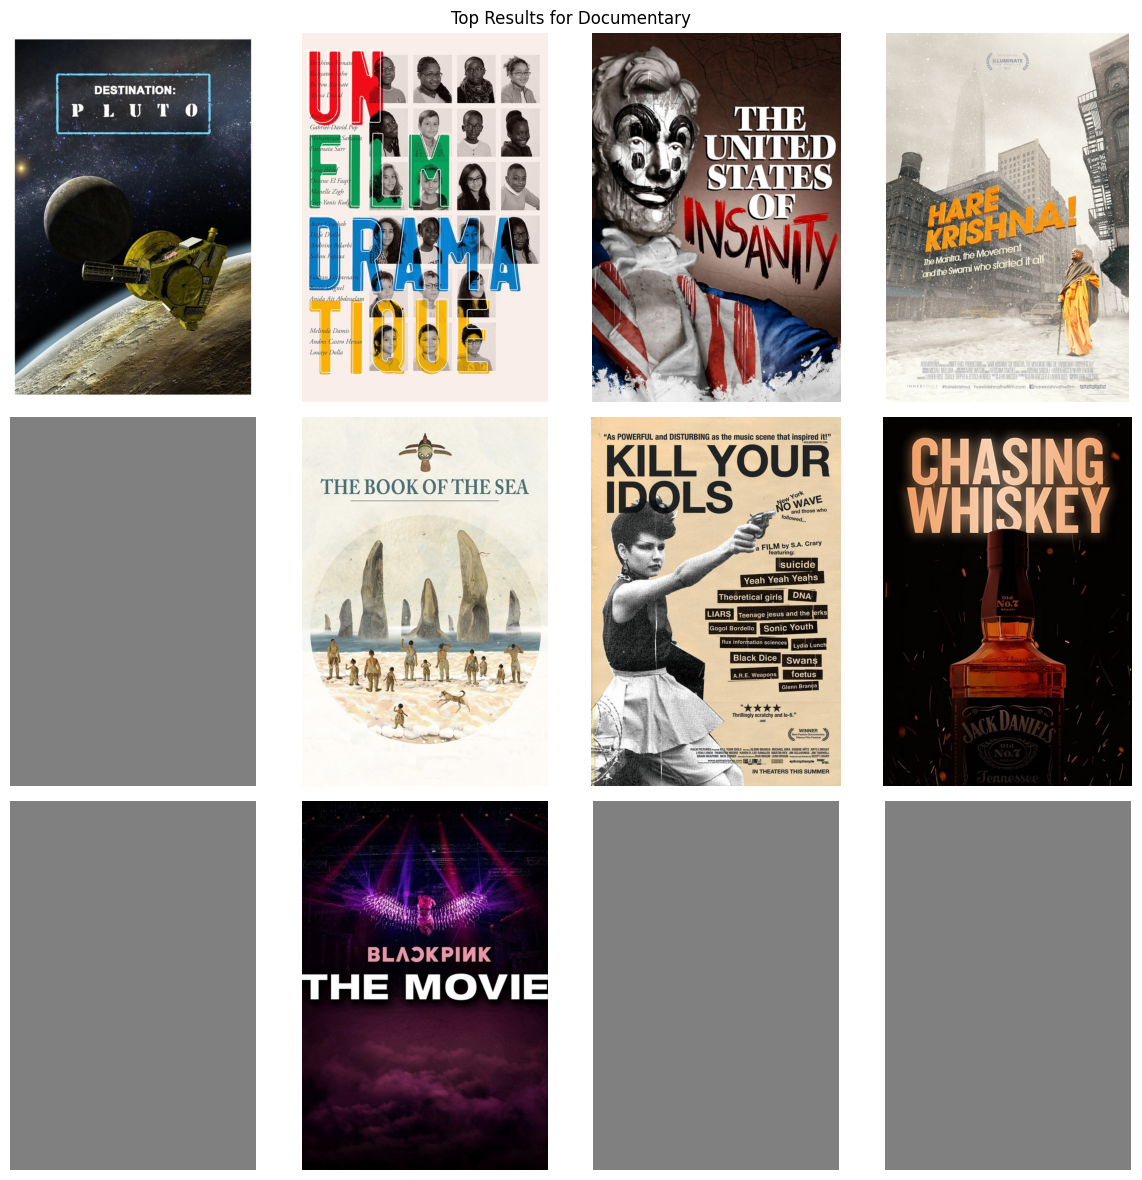

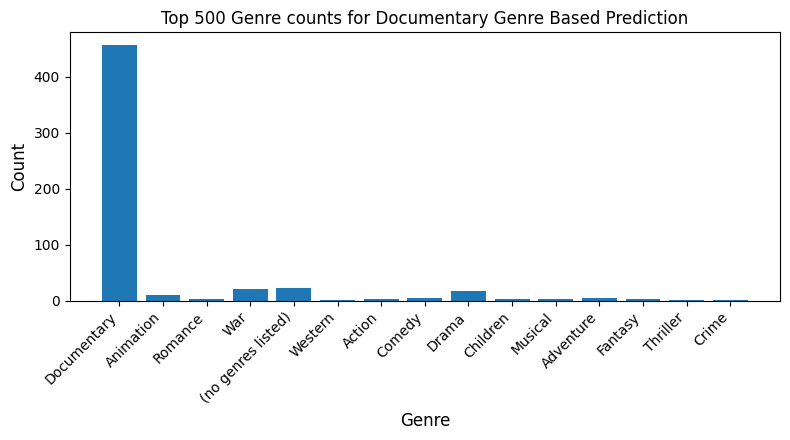

In [52]:
dummy_user_genre_ratings=[
    ["Documentary", 5],

]

print("USER CHOICES")
print_genre_choices(dummy_user_genre_ratings)

selection=myModel_saved.predict(dummy_user_genre_ratings,10,genre_only=True, show_stats=True)
#printing predicted results
print_selection(selection)

print_selection_summary_latex_genre(selection)
#displaying movie posters
search_title = f"Top Results for {', '.join([r[0] for r in dummy_user_genre_ratings])}"

generate_movie_grid(data_structure,selection,search_title=search_title,title='dummy_genre_pred', data_title=DATA_TITLE, split_strategy=SPLIT_STRATEGY)

genres=[]
for i in range(1):
    selection=myModel_saved.predict(dummy_user_genre_ratings,500,genre_only=True, remove_polarized = False)

    for m in selection:
          genres.append(m['genre'])
#plotting histogram of genres in top 500 results in prediction
plot_genres(genres,top=500, title="genre_pred_stats" ,search = f'for {str(dummy_user_genre_ratings[0][0])} Genre Based Prediction', data_title=DATA_TITLE, split_strategy=SPLIT_STRATEGY)
